In [1]:
# Isaac Berez
# 17.01.23
import sys
from scipy.io import mmread
import os
import glob
import pandas as pd
import numpy as np
#from pandas_ods_reader import read_ods
from copy import deepcopy
import pprint
import json
import re
from datetime import datetime
import logging
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import HuberRegressor
from sklearn import preprocessing
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform
from sklearn.manifold import TSNE
from sklearn import metrics
from sklearn.cluster import DBSCAN
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from collections import Counter
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import harmonypy as hm
from matplotlib.cm import ScalarMappable
from datetime import date
import mpld3
import hvplot.pandas
import holoviews as hv
from holoviews import opts
import panel as pn
import bokeh
from bokeh.resources import INLINE
import csv
import scanpy as sc
import anndata as ad
import matplotlib as mpl 

import dimorph_processing as dp
import dimorph_processing_rc as dp_rc
import dimorph_processing_c as dp_c


today = str(date.today())
%matplotlib notebook
%load_ext autoreload
%autoreload 2

#change matplotlib font type to make compatibile with illustrator
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Table of Contents
1. [Introduction](#introduction)
2. [Data Loading](#data_loading)
3. [GABA Analysis](#gaba_analysis)
4. [Vglut1 Analysis](#vglut1_analysis)
5. [Vglut2 Analysis](#vglut2_analysis)
6. [Nonneuronal Analysis](#nn_analysis)

## Introduction <a name="introduction"></a>

Continuation of NN parallel analysis 

## Data Loading <a name="data_loading"></a>

In [2]:
today

'2025-04-14'

Load the original gene expression dataframe, then use an updated metafile to filter cells (previously performed in cell exclusion step of 'dimorph_processing_nb.ipynb')

In [2]:
df_orig = pd.read_feather('/bigdata/isaac/df_orig.feather')

#meta_data_df = pd.read_json('/bigdata/isaac/meta_data_df2024-05-01.json')

#use 2024-05-09 version of metadata - which fixed a bug in compute marker means () where prev NN cells were not being summed
#meta_data_df = pd.read_json('/bigdata/isaac/meta_data_df_mm_2024-05-09.json')

#latest metadata version 2024-05-19
meta_data_df = pd.read_json('/bigdata/isaac/NN_l1_meta_data_df_mm_2025-04-14.json')

In [4]:
Counter(np.array(meta_data_df.loc['cell_class',:]))

Counter({'GABA': 26724,
         'Nonneuronal': 13990,
         'Vglut1': 12689,
         'Vglut2': 3264,
         'Doublet': 1598})

In [5]:
print (len(np.where(df_orig.sum(axis=1)==0)[0]))

4963


In [6]:
sex_gene_list = []

with open('/bigdata/isaac/sex_gene_list.txt', 'r') as fh:
    for g in fh:
        sex_gene_list.append(g[:-1])

In [7]:
IEG_list = []

with open('/bigdata/isaac/IEG_cluster.txt', 'r') as fh:
    for g in fh:
        IEG_list.append(g[:-1])

In [8]:
df_orig.head()

,AAACCCAAGAGCATAT-1_10X51_2,AAACCCAAGCCTCAGC-1_10X51_2,AAACCCAAGTACTGTC-1_10X51_2,AAACCCACACAACGTT-1_10X51_2,AAACCCAGTAACATAG-1_10X51_2,AAACCCATCACTAGCA-1_10X51_2,AAACGAACACTCCGAG-1_10X51_2,AAACGAACAGCGCGTT-1_10X51_2,AAACGAACAGGACTTT-1_10X51_2,AAACGAAGTGAATAAC-1_10X51_2,...,TTTGGTTTCCACGAAT-1_10X37_2,TTTGGTTTCTTTCTAG-1_10X37_2,TTTGTTGAGAAATTCG-1_10X37_2,TTTGTTGAGTGCTCGC-1_10X37_2,TTTGTTGCAAGGTCAG-1_10X37_2,TTTGTTGCACCGCTGA-1_10X37_2,TTTGTTGGTCCATAGT-1_10X37_2,TTTGTTGGTTGCGAAG-1_10X37_2,TTTGTTGTCGAAGGAC-1_10X37_2,TTTGTTGTCTCTGCTG-1_10X37_2
gene,,,,,,,,,,,,,,,,,,,,,
0610007P14Rik,0,2,0,2,0,0,1,3,2,0,...,1,0,1,0,2,1,1,0,0,0
0610009B22Rik,0,0,0,1,0,2,2,0,1,0,...,0,0,0,0,2,0,0,0,0,0
0610009L18Rik,0,0,0,0,0,0,1,1,0,0,...,0,0,0,0,1,0,1,0,0,0
0610009O20Rik,1,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0610010F05Rik,0,0,1,0,0,0,2,1,1,0,...,1,0,2,0,1,0,1,0,0,0


In [9]:
meta_data_df

,CTCCTCCCAGCTGTCG-1_10X51_1,TGAGGAGAGACTGAGC-1_10X35_1,CATGCTCGTAGTGTGG-1_10X51_3,TGAACGTTCATTGCGA-1_10X37_1,GACCAATCACTGCACG-1_10X51_4,AAAGTCCGTTGGGCCT-1_10X52_2,TCTACATGTGACATCT-1_10X37_1,GTCCTCAGTCTGATAC-1_10X37_2,CTCAGAACAGCTGTTA-1_10X37_1,ATGGGAGGTACCACGC-1_10X38_2,...,ATCCTATCAAAGACGC-1_10X36_1,CCCTCAATCATGTCAG-1_10X38_2,AGTTCGAAGGTAGGCT-1_10X51_3,TTCACCGTCACAAGAA-1_10X52_4,CTGGTCTTCCAGTACA-1_10X51_1,ACATCGATCCGATCGG-1_10X36_2,CATCCACGTGAGCAGT-1_10X36_2,CCTCCTCCAACTAGAA-1_10X51_1,CTGAGCGCACAAATAG-1_10X38_1,ACTGCAATCGGACGTC-1_10X37_2
Serial_Number,97.0,63.0,99.0,67.0,100.0,102.0,67.0,68.0,67.0,70.0,...,65.0,70.0,99.0,104.0,97.0,66.0,66.0,97.0,69.0,68.0
Date_Captured,05/31/20,2019-11-20,05/31/20,2019-11-25,05/31/20,05/31/20,2019-11-25,2019-11-25,2019-11-25,2019-12-01,...,2019-11-24,2019-12-01,05/31/20,05/31/20,05/31/20,2019-11-24,2019-11-24,05/31/20,2019-12-01,2019-11-25
Species,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,...,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm
Transcriptome,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,...,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10
Strain,C57Bl/6,,C57Bl/6,,C57Bl/6,C57Bl/6,,,,,...,,,C57Bl/6,C57Bl/6,C57Bl/6,,,C57Bl/6,,
Project,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,...,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph
Group,Breeder-F,Naïve-F,Breeder-M,Naïve-M,Breeder-M,Breeder-F,Naïve-M,Naïve-M,Naïve-M,Naïve-F,...,Naïve-M,Naïve-F,Breeder-M,Breeder-M,Breeder-F,Naïve-M,Naïve-M,Breeder-F,Naïve-F,Naïve-M
ChipID,10X51,10X35,10X51,10X37,10X51,10X52,10X37,10X37,10X37,10X38,...,10X36,10X38,10X51,10X52,10X51,10X36,10X36,10X51,10X38,10X37
SampleID,10X51_1,10X35_1,10X51_3,10X37_1,10X51_4,10X52_2,10X37_1,10X37_2,10X37_1,10X38_2,...,10X36_1,10X38_2,10X51_3,10X52_4,10X51_1,10X36_2,10X36_2,10X51_1,10X38_1,10X37_2
DonorID,DI-B1-F,"DI1,DI2",DI-B1-M,"DI4,DI5",DI-B1-M,DI-B3-F,"DI4,DI5","DI4,DI5","DI4,DI5",DI6,...,DI3,DI6,DI-B1-M,DI-B3-M,DI-B1-F,DI3,DI3,DI-B1-F,DI6,"DI4,DI5"


In [10]:
meta_data_df.tail()

,CTCCTCCCAGCTGTCG-1_10X51_1,TGAGGAGAGACTGAGC-1_10X35_1,CATGCTCGTAGTGTGG-1_10X51_3,TGAACGTTCATTGCGA-1_10X37_1,GACCAATCACTGCACG-1_10X51_4,AAAGTCCGTTGGGCCT-1_10X52_2,TCTACATGTGACATCT-1_10X37_1,GTCCTCAGTCTGATAC-1_10X37_2,CTCAGAACAGCTGTTA-1_10X37_1,ATGGGAGGTACCACGC-1_10X38_2,...,ATCCTATCAAAGACGC-1_10X36_1,CCCTCAATCATGTCAG-1_10X38_2,AGTTCGAAGGTAGGCT-1_10X51_3,TTCACCGTCACAAGAA-1_10X52_4,CTGGTCTTCCAGTACA-1_10X51_1,ACATCGATCCGATCGG-1_10X36_2,CATCCACGTGAGCAGT-1_10X36_2,CCTCCTCCAACTAGAA-1_10X51_1,CTGAGCGCACAAATAG-1_10X38_1,ACTGCAATCGGACGTC-1_10X37_2
ngperul_seqlib,19.2,13.6,22.0,15.9,23.6,17.5,15.9,16.0,15.9,18.7,...,11.4,18.7,22.0,8.94 (second prep),19.2,12.1,12.1,19.2,15.0,16.0
lengthbp_seqlib,478.0,416.0,487.0,440.0,415.0,440.0,440.0,460.0,440.0,415.0,...,476.0,415.0,487.0,535.0,478.0,486.0,486.0,478.0,420.0,460.0
Sample_Index,G1,D9,B2,E9,C2,E12,E9,F9,E9,C9,...,H8,C9,B2,G12,G1,A9,A9,G1,B9,F9
cluster_label,28,28,28,28,28,28,28,28,28,28,...,7,7,7,7,7,7,7,7,7,7
cell_class,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,...,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal


remove old cluster labels from original analysis to avoid confusion

In [11]:
meta_data_df = meta_data_df.drop(['cluster_label'])

In [12]:
df = df_orig.reindex(columns=meta_data_df.columns)

In [13]:
df.shape

(27933, 58265)

In [14]:
df.head()

,CTCCTCCCAGCTGTCG-1_10X51_1,TGAGGAGAGACTGAGC-1_10X35_1,CATGCTCGTAGTGTGG-1_10X51_3,TGAACGTTCATTGCGA-1_10X37_1,GACCAATCACTGCACG-1_10X51_4,AAAGTCCGTTGGGCCT-1_10X52_2,TCTACATGTGACATCT-1_10X37_1,GTCCTCAGTCTGATAC-1_10X37_2,CTCAGAACAGCTGTTA-1_10X37_1,ATGGGAGGTACCACGC-1_10X38_2,...,ATCCTATCAAAGACGC-1_10X36_1,CCCTCAATCATGTCAG-1_10X38_2,AGTTCGAAGGTAGGCT-1_10X51_3,TTCACCGTCACAAGAA-1_10X52_4,CTGGTCTTCCAGTACA-1_10X51_1,ACATCGATCCGATCGG-1_10X36_2,CATCCACGTGAGCAGT-1_10X36_2,CCTCCTCCAACTAGAA-1_10X51_1,CTGAGCGCACAAATAG-1_10X38_1,ACTGCAATCGGACGTC-1_10X37_2
gene,,,,,,,,,,,,,,,,,,,,,
0610007P14Rik,0,4,1,1,1,0,0,0,1,0,...,0,0,0,1,0,1,1,0,0,0
0610009B22Rik,0,0,0,0,0,1,0,0,0,0,...,0,0,2,0,0,0,1,0,0,0
0610009L18Rik,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
0610009O20Rik,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
0610010F05Rik,2,2,0,0,0,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0


In [15]:
meta_data_df.tail()

,CTCCTCCCAGCTGTCG-1_10X51_1,TGAGGAGAGACTGAGC-1_10X35_1,CATGCTCGTAGTGTGG-1_10X51_3,TGAACGTTCATTGCGA-1_10X37_1,GACCAATCACTGCACG-1_10X51_4,AAAGTCCGTTGGGCCT-1_10X52_2,TCTACATGTGACATCT-1_10X37_1,GTCCTCAGTCTGATAC-1_10X37_2,CTCAGAACAGCTGTTA-1_10X37_1,ATGGGAGGTACCACGC-1_10X38_2,...,ATCCTATCAAAGACGC-1_10X36_1,CCCTCAATCATGTCAG-1_10X38_2,AGTTCGAAGGTAGGCT-1_10X51_3,TTCACCGTCACAAGAA-1_10X52_4,CTGGTCTTCCAGTACA-1_10X51_1,ACATCGATCCGATCGG-1_10X36_2,CATCCACGTGAGCAGT-1_10X36_2,CCTCCTCCAACTAGAA-1_10X51_1,CTGAGCGCACAAATAG-1_10X38_1,ACTGCAATCGGACGTC-1_10X37_2
LIbConstructionComment,,,,,,,,,,,...,,,,,,,,,,
ngperul_seqlib,19.2,13.6,22.0,15.9,23.6,17.5,15.9,16.0,15.9,18.7,...,11.4,18.7,22.0,8.94 (second prep),19.2,12.1,12.1,19.2,15.0,16.0
lengthbp_seqlib,478.0,416.0,487.0,440.0,415.0,440.0,440.0,460.0,440.0,415.0,...,476.0,415.0,487.0,535.0,478.0,486.0,486.0,478.0,420.0,460.0
Sample_Index,G1,D9,B2,E9,C2,E12,E9,F9,E9,C9,...,H8,C9,B2,G12,G1,A9,A9,G1,B9,F9
cell_class,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,...,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal


In [16]:
np.all(meta_data_df.columns == df.columns)

True

## Nonneuronal Analysis <a name="nn_analysis"></a>

In [17]:
np.unique(meta_data_df.loc['cell_class'])

array(['Doublet', 'GABA', 'Nonneuronal', 'Vglut1', 'Vglut2'], dtype=object)

In [18]:
#check loc of epenymal cells from 2_17 metadata
NN_metadata_df_plis_F_markers_feb17 = pd.read_json('/bigdata/isaac/Nonneuronal_files/filtered_merged/NNmeta_data_df_plis_f_markers_2025-02-17.json')
epend_columns = NN_metadata_df_plis_F_markers_feb17.loc[:,NN_metadata_df_plis_F_markers_feb17.loc['markers',:] == 'Epend'].columns

In [74]:
NN_metadata_df_plis_F_markers_feb17.shape

(31, 1961)

In [27]:
np.unique(NN_metadata_df_plis_F_markers_feb17.loc['markers'])

array(['Astro', 'Astro_gfap', 'Endothelial', 'Epend', 'Microglia', 'OL_1',
       'OL_2', 'OL_3', 'OPC', 'Proliferating_cells', 'VSM'], dtype=object)

In [19]:
epend_columns

Index(['GTGAGGATCTCCAATT-1_10X37_2', 'ACCACAAGTATCGGTT-1_10X35_2',
       'ATGACCAAGAAGCGGG-1_10X52_1', 'TCCGTGTGTAGATTAG-1_10X37_2',
       'TGCATCCTCCGTTTCG-1_10X36_1', 'GTGTGGCAGCCACTCG-1_10X37_1',
       'CTGCTCAAGACAGCTG-1_10X35_2', 'AGCTTCCGTCCTTTGC-1_10X35_1',
       'TCGAACATCGGTTAGT-1_10X51_4', 'AGTCTCCAGGAACGAA-1_10X37_1',
       'TCTGTCGGTCACCACG-1_10X35_1', 'CCTTCAGTCAGCCTCT-1_10X36_1',
       'CAGGTATGTAAGATAC-1_10X52_2', 'ATCTCTAGTGGCCTCA-1_10X36_1',
       'CCCTAACAGCCGTTGC-1_10X35_2', 'TGCTCCAGTAACAGGC-1_10X37_2',
       'GTTCCGTTCCGACGGT-1_10X35_2', 'AGGGAGTAGAAGCCAC-1_10X37_2',
       'CTTGAGAGTTATTCTC-1_10X35_2', 'GTAATGCCACATGAAA-1_10X52_2',
       'CAACAACGTGTCATTG-1_10X37_1', 'CGTGCTTGTCTGTCAA-1_10X37_2',
       'ACGTACAGTACAGTAA-1_10X52_2', 'AAGTCGTTCGCCTATC-1_10X38_1',
       'CTCGAGGTCATCGCAA-1_10X35_2'],
      dtype='object')

In [20]:
set(epend_columns).issubset(set(df.columns))

True

In [70]:
#sanity check with astro
VSM = NN_metadata_df_plis_F_markers_feb17.loc[:,NN_metadata_df_plis_F_markers_feb17.loc['markers',:] == 'VSM'].columns

In [71]:
VSM.shape

(106,)

In [72]:
set(VSM).issubset(set(df.columns))

True

In [73]:
common_columns = set(VSM).intersection(set(df.columns))
print(f"Number of common columns: {len(common_columns)}")

Number of common columns: 106


## 1) Process (L2)

num m cells: 6420 num f cells: 7570


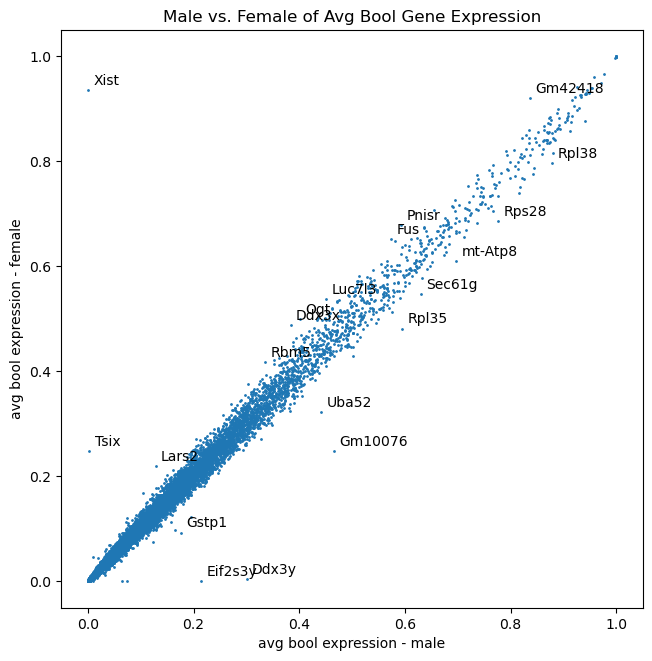

Total genes reduced from 27933 to 16474
removing  5  genes found in  ['Xist', 'Tsix', 'Ddx3y', 'Eif2s3y', 'Kdm5d', 'Uty']
removing  52  genes found in  ['Btg2', 'Jun', 'Egr4', 'Fosb', 'Junb', 'Gadd45g', 'Fos', 'Arc', 'Nr4a1', 'Npas4', 'Coq10b', 'Tns1', 'Per2', 'Ptgs2', 'Rnd3', 'Tnfaip6', 'Srxn1', 'Tiparp', 'Ccnl1', 'Mcl1', 'Dnajb5', 'Nr4a3', 'Fosl2', 'Nptx2', 'Rasl11a', 'Mest', 'Sertad1', 'Egr2', 'Midn', 'Gadd45b', 'Dusp6', 'Irs2', 'Plat', 'Ier2', 'Rrad', 'Tpbg', 'Csrnp1', 'Peli1', 'Per1', 'Kdm6b', 'Inhba', 'Plk2', 'Ifrd1', 'Baz1a', 'Trib1', 'Pim3', 'Lrrk2', 'Dusp1', 'Cdkn1a', 'Pim1', 'Sik1', 'Frat2', 'Dusp5']
It contains 0 infinite values


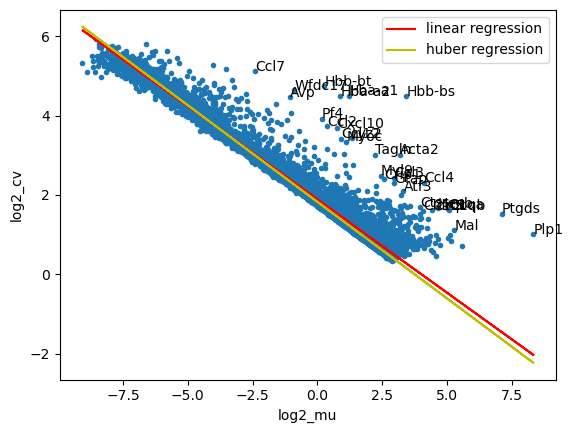

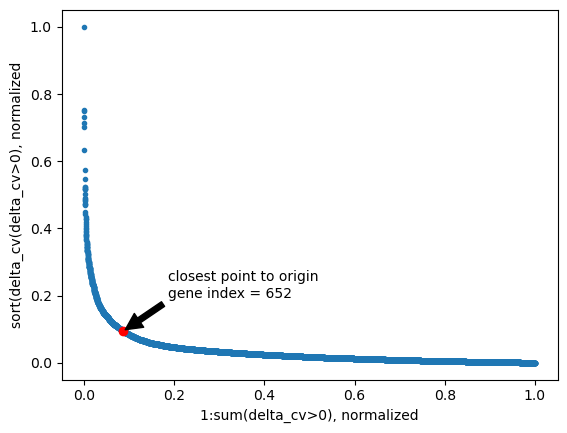

(652, 13990)
It contains 0 infinite values
#nan values 0
column (gene) mean after standardization: 0.00
column (gene) sigma after standardization: 1.00


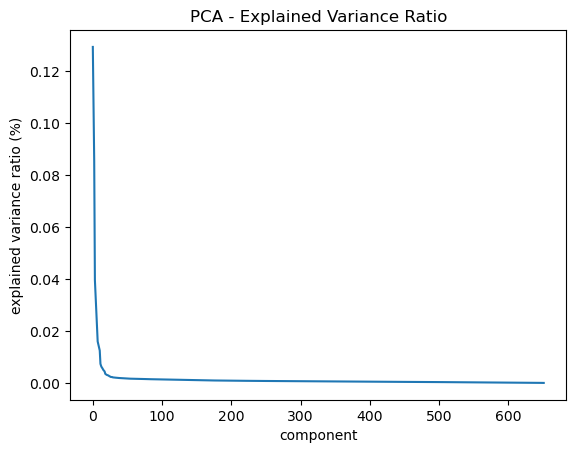

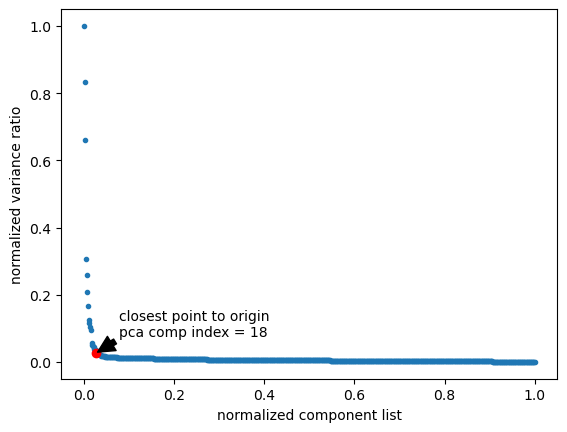

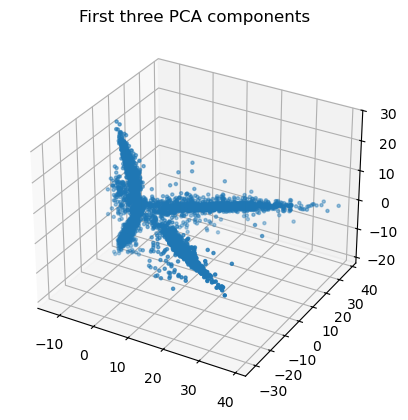

2025-04-14 15:47:57,163 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-04-14 15:47:58,456 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-04-14 15:47:58,514 - harmonypy - INFO - Iteration 1 of 20
2025-04-14 15:48:01,508 - harmonypy - INFO - Iteration 2 of 20
2025-04-14 15:48:04,688 - harmonypy - INFO - Iteration 3 of 20
2025-04-14 15:48:06,012 - harmonypy - INFO - Iteration 4 of 20
2025-04-14 15:48:07,036 - harmonypy - INFO - Iteration 5 of 20
2025-04-14 15:48:08,015 - harmonypy - INFO - Iteration 6 of 20
2025-04-14 15:48:09,004 - harmonypy - INFO - Iteration 7 of 20
2025-04-14 15:48:09,963 - harmonypy - INFO - Iteration 8 of 20
2025-04-14 15:48:10,920 - harmonypy - INFO - Iteration 9 of 20
2025-04-14 15:48:11,883 - harmonypy - INFO - Converged after 9 iterations


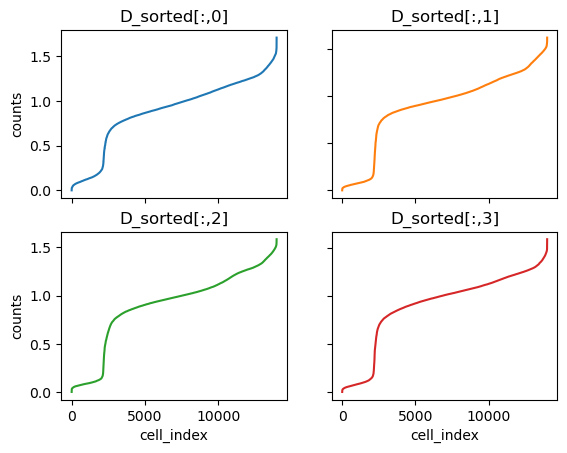

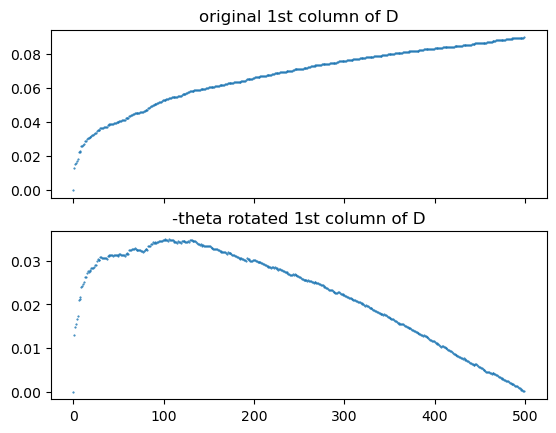

running TSNE with NN parameters
creating tsne object with the following parameters: 
n_components:2
n_iter: 1000
learning_rate: 1165
early_exaggeration: 20
init: pca
perplexity: 65.0


/home/isaac/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


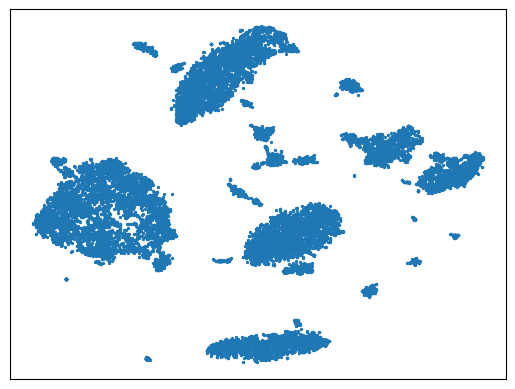

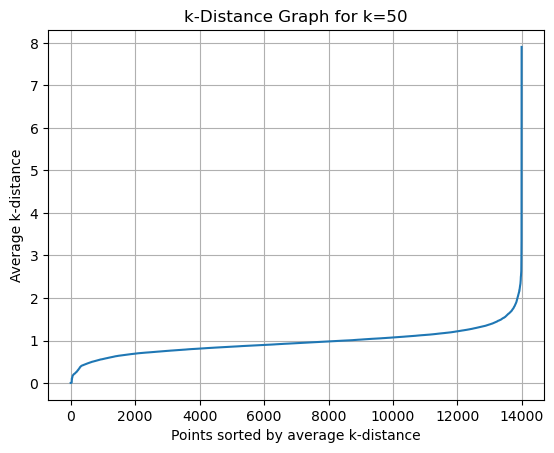

The knee is at x = 13682, y = 1.6994569006853104


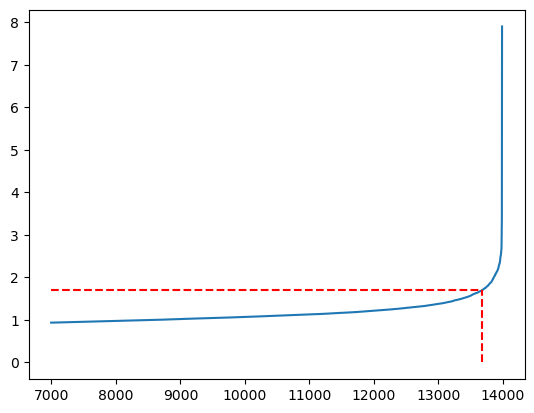

running dbscan with epsilon: 1.6994569006853104  and minpts: 20
Estimated number of clusters: 32
Estimated number of noise points: 287


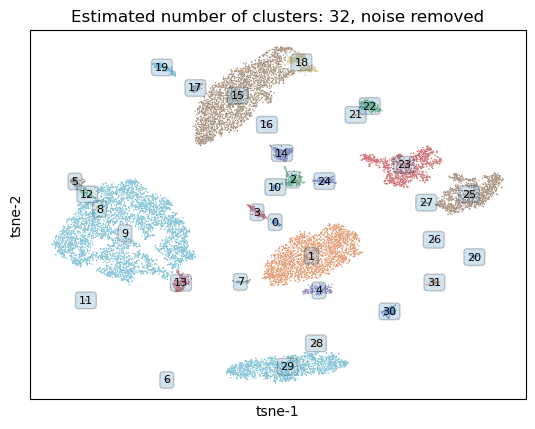

verify raw prelinkage df and raw metadata df have same columns:
True


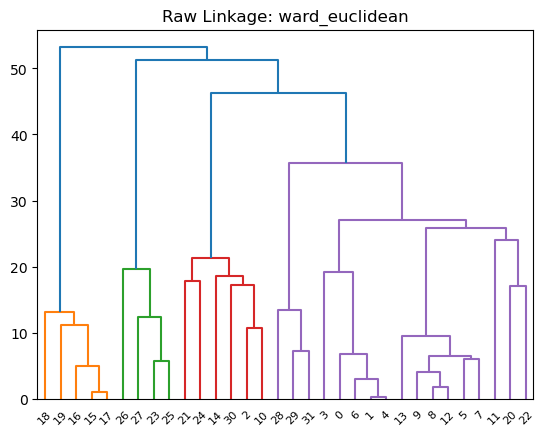

[18 16 17 15 19  3  0  1  4  6 13  9  8 12  5  7 22 20 11 31 29 28 14 10
  2 30 21 24 27 25 23 26]


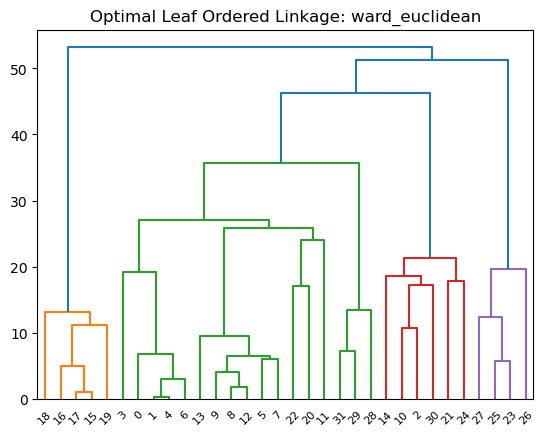

metadata df shape post inter cluster sort
(29, 13703)


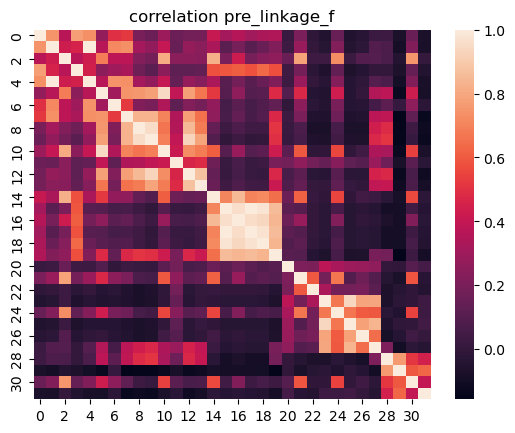

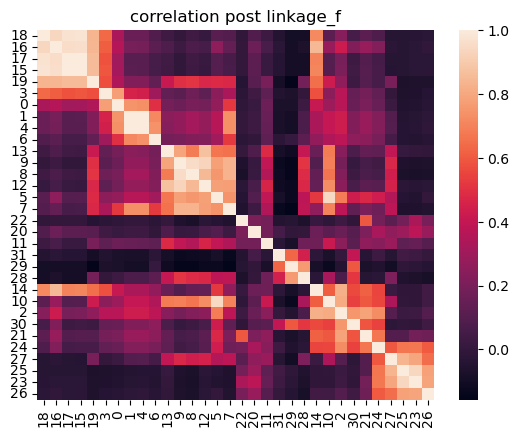

{18: 1, 16: 2, 17: 3, 15: 4, 19: 5, 3: 6, 0: 7, 1: 8, 4: 9, 6: 10, 13: 11, 9: 12, 8: 13, 12: 14, 5: 15, 7: 16, 22: 17, 20: 18, 11: 19, 31: 20, 29: 21, 28: 22, 14: 23, 10: 24, 2: 25, 30: 26, 21: 27, 24: 28, 27: 29, 25: 30, 23: 31, 26: 32}
[0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27
 28 29 30 31]
check if df plis columns equal metadata df plis columns:
[ True  True  True ...  True  True  True]
len marker_Genes_sorted 173
len marker_genes_sorted_final 173
column (gene) mean after standardization: -0.00
column (gene) sigma after standardization: 1.00
Indices where the value changes: [0, 251, 282, 335, 2619, 2769, 2915, 2965, 4869, 5022, 5081, 5277, 8995, 9015, 9069, 9151, 9211, 9418, 9484, 9516, 9600, 10938, 10977, 11187, 11237, 11437, 11568, 11588, 11719, 11743, 12705, 13664, 13702]
[0, 5, 6, 7, 8, 9, 10, 11, 12, 13, 16, 17, 18, 19, 20, 21, 22, 23, 26, 27, 30, 31]
22
[array([ 0,  1,  2,  3,  4, 21, 22,  9, 19,  6, 18, 17, 15, 16, 13, 14,  8,
        7, 11, 1

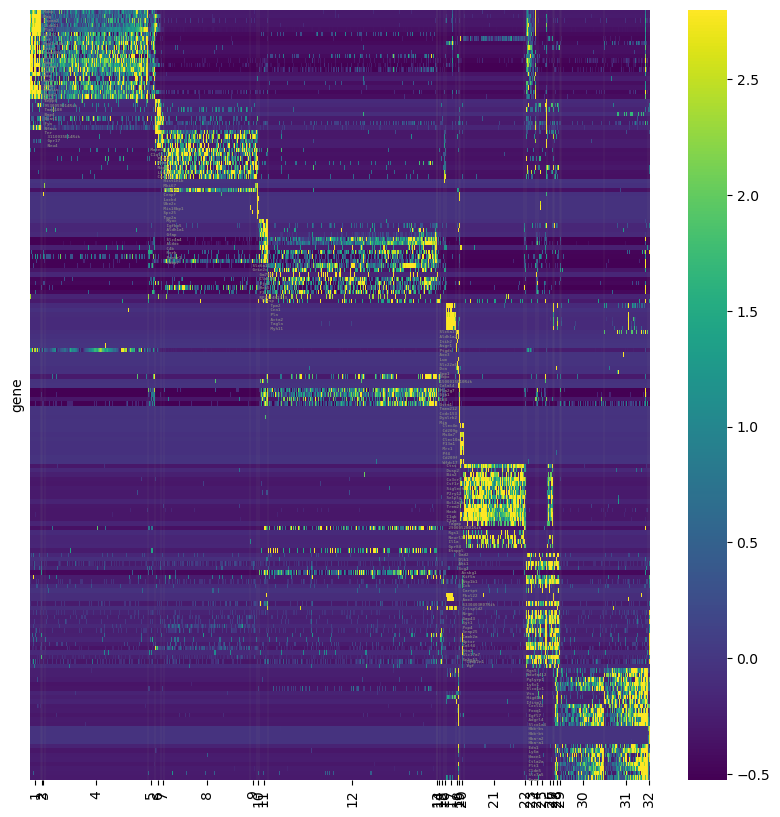

True


In [76]:
%matplotlib inline
#try new process module
NN_folder = '/bigdata/isaac/Nonneuronal_files/'
NN_df_marker, NN_arr_tsne, NN_meta_data_df_plis, NN_linkage_cluster_order, NN_df_marker_log_and_std_col, NN_df_plis, NN_cluster_indices, NN_df_marker_log_and_std, NN_df_ge, NN_df_n = dp_c.process(df_orig, meta_data_df, sex_gene_list, IEG_list, NN_folder, 'Nonneuronal')


In [131]:
Counter(NN_meta_data_df_plis.loc['cluster_label',:])

Counter({12: 3718,
         4: 2284,
         8: 1904,
         21: 1338,
         30: 962,
         31: 959,
         1: 251,
         23: 210,
         17: 207,
         25: 200,
         11: 196,
         9: 153,
         5: 150,
         6: 146,
         26: 131,
         28: 131,
         20: 84,
         15: 82,
         18: 66,
         16: 60,
         10: 59,
         14: 54,
         3: 53,
         7: 50,
         24: 50,
         22: 39,
         32: 39,
         19: 32,
         2: 31,
         29: 24,
         13: 20,
         27: 20})

In [78]:
np.unique(NN_meta_data_df_plis.loc['cluster_label',:]) 

array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
       20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32], dtype=object)

In [79]:
NN_meta_data_df_plis.loc[:,NN_meta_data_df_plis.loc['cluster_label',:] == 10].shape[1]

59

In [26]:
for id in np.unique(NN_meta_data_df_plis.loc['cluster_label',:]):
    if NN_meta_data_df_plis.loc[:,NN_meta_data_df_plis.loc['cluster_label',:] == id].shape[1] == 39:
        print (id)

In [27]:
NN_arr_tsne.shape

(14041, 2)

In [28]:
NN_meta_data_df_plis.shape

(29, 13954)

/tmp/ipykernel_1329735/2934346080.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(NN_linkage_cluster_order, rotation = 90)


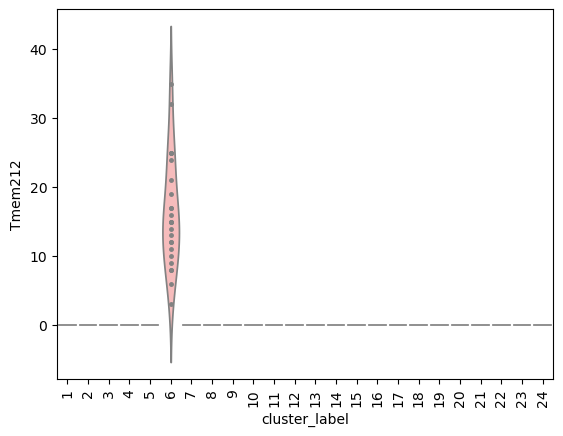

In [183]:
#check some specific expression of genes
gene = 'Tmem212'
%matplotlib inline
fig,ax = plt.subplots()
sns.violinplot(x=NN_meta_data_df_plis.T['cluster_label'], y=NN_df_plis.T[gene], inner = 'point')
#sns.stripplot(x=amy_vglut2_md.T['full_name'], y=amy_vglut2_ce_ge_cv_ls.T[gene], color="k", size=3)
ax.set_xticklabels(NN_linkage_cluster_order, rotation = 90)
plt.show()

# 2) Drop clusters, filter heatmap elements

/tmp/ipykernel_3357189/3992831856.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(NN_linkage_cluster_order, rotation = 90)


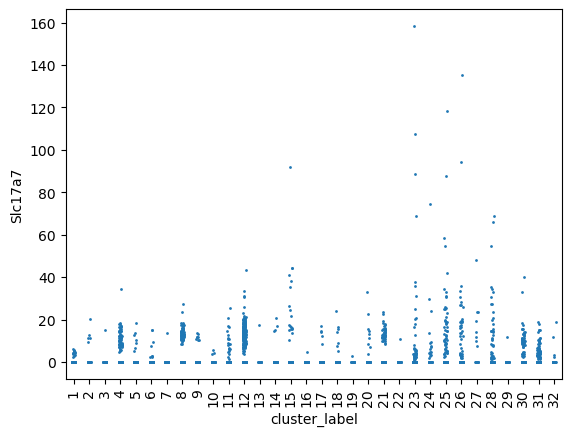

In [86]:
#check some specific expression of genes
gene = 'Slc17a7'
%matplotlib inline
fig,ax = plt.subplots()
#sns.violinplot(x=NN_meta_data_df_plis.T['cluster_label'], y=NN_df_n.T[gene], inner = 'point')
#sns.objects.jitter(width = 0.5, x=NN_meta_data_df_plis.T['cluster_label'], y=NN_df_n.T[gene])
sns.stripplot(x=NN_meta_data_df_plis.T['cluster_label'], y=NN_df_n.T[gene], jitter = True, size = 2)
ax.set_xticklabels(NN_linkage_cluster_order, rotation = 90)
plt.show()

/tmp/ipykernel_3357189/2241271340.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(NN_linkage_cluster_order, rotation = 90)


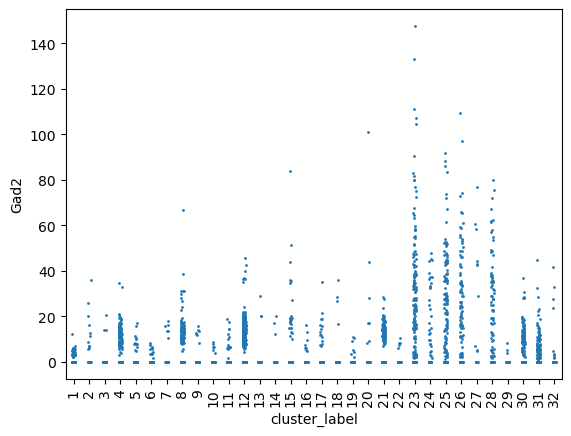

In [87]:
#check some specific expression of genes
gene = 'Gad2'
%matplotlib inline
fig,ax = plt.subplots()
#sns.violinplot(x=NN_meta_data_df_plis.T['cluster_label'], y=NN_df_n.T[gene], inner = 'point')
#sns.objects.jitter(width = 0.5, x=NN_meta_data_df_plis.T['cluster_label'], y=NN_df_n.T[gene])
sns.stripplot(x=NN_meta_data_df_plis.T['cluster_label'], y=NN_df_n.T[gene], jitter = True, size = 2)
ax.set_xticklabels(NN_linkage_cluster_order, rotation = 90)
plt.show()

In [115]:
df_tmp = df_orig.reindex(columns = NN_df_n.columns)
_,df_tmp_n = dp.analyze_cv(df_tmp,20000,5,0) 

/tmp/ipykernel_3357189/900939888.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(NN_linkage_cluster_order, rotation = 90)


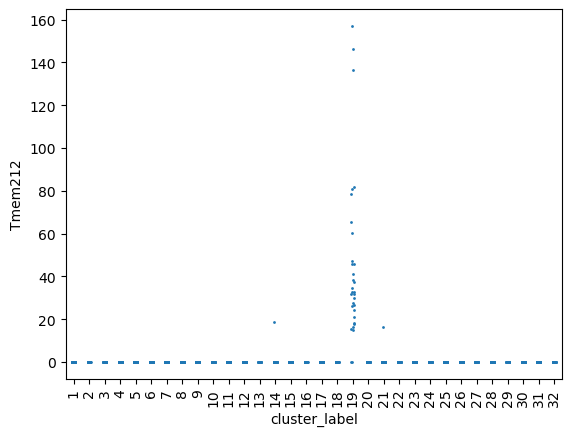

In [98]:
#check some specific expression of genes
gene = 'Tmem212'
%matplotlib inline
fig,ax = plt.subplots()
#sns.violinplot(x=NN_meta_data_df_plis.T['cluster_label'], y=NN_df_n.T[gene], inner = 'point')
#sns.objects.jitter(width = 0.5, x=NN_meta_data_df_plis.T['cluster_label'], y=NN_df_n.T[gene])
sns.stripplot(x=NN_meta_data_df_plis.T['cluster_label'], y=NN_df_n.T[gene], jitter = True, size = 2)
ax.set_xticklabels(NN_linkage_cluster_order, rotation = 90)
plt.show()

In [28]:
NN_arr_tsne.shape

(14041, 2)

In [34]:
NN_df_n.shape

(16298, 14041)

gene in df?  True
gene index:  [7300]


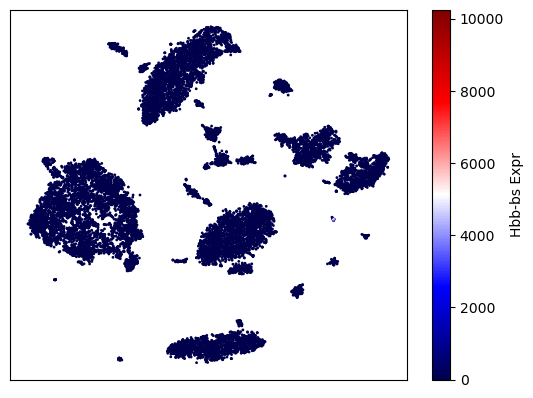

In [100]:
gene = 'Hbb-bs'
print('gene in df? ', gene in NN_df_n.index)
print ('gene index: ', np.where(NN_df_n.index == gene)[0])

x = NN_arr_tsne[:, 0]
y = NN_arr_tsne[:, 1]
z = np.array(NN_df_n.loc[gene,:])

#visualise tsne
fig, ax = plt.subplots()
scatter = ax.scatter(x, y, c = z , cmap = 'seismic' , s = 1)

# Create colorbar
sm = ScalarMappable(cmap='seismic')
sm.set_array(z)
# Create colorbar
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label(gene + ' Expr')

plt.xticks([])
plt.yticks([])

plt.show()

In [21]:
NN_df_plis

,CAAGACTTCCAACACA-1_10X35_1,AGAGCAGTCACCTGTC-1_10X35_1,ATGAGGGAGCACCTGC-1_10X35_1,CAACGATGTAGGTAGC-1_10X35_1,CTCATGCGTGCCCACA-1_10X35_1,CTGCGAGCAAACCACT-1_10X37_1,CGAGGCTAGGACCCAA-1_10X35_1,TTTATGCCAACCTATG-1_10X35_1,TCGCTCATCCACGAAT-1_10X35_1,TGATGCATCATCGCTC-1_10X35_2,...,TCTTTGACACCGTGGT-1_10X35_2,CTACGGGTCGCCAGTG-1_10X37_2,CACGTGGAGCGGTATG-1_10X38_2,TACGGTACATGGCACC-1_10X37_1,TCCTGCAAGCTAGCCC-1_10X35_2,ACGTAGTCAGCCTATA-1_10X38_1,CCGGTAGGTCCAGTTA-1_10X37_1,GATCATGTCGTCCATC-1_10X35_1,TTGCTGCGTTACCCTC-1_10X37_1,ACTTATCCACCAGACC-1_10X37_1
gene,,,,,,,,,,,,,,,,,,,,,
Plp1,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,3,0,1,1,1
Ptgds,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
Acta2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Ccl4,0,0,0,0,0,1,0,0,0,0,...,0,10,0,0,0,0,0,0,0,0
Wfdc17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zfp36l1,0,2,14,5,1,2,0,0,0,2,...,10,13,19,16,18,24,14,21,22,30
C5ar1,2,0,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
Gpr65,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


/tmp/ipykernel_3059141/1156716442.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(NN_linkage_cluster_order, rotation = 90)


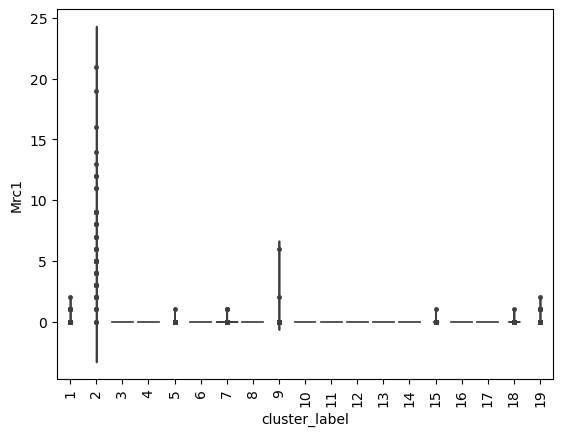

/tmp/ipykernel_3059141/1156716442.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(NN_linkage_cluster_order, rotation = 90)


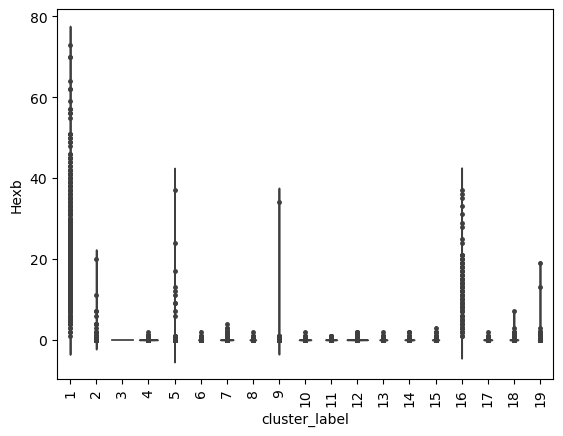

/tmp/ipykernel_3059141/1156716442.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(NN_linkage_cluster_order, rotation = 90)


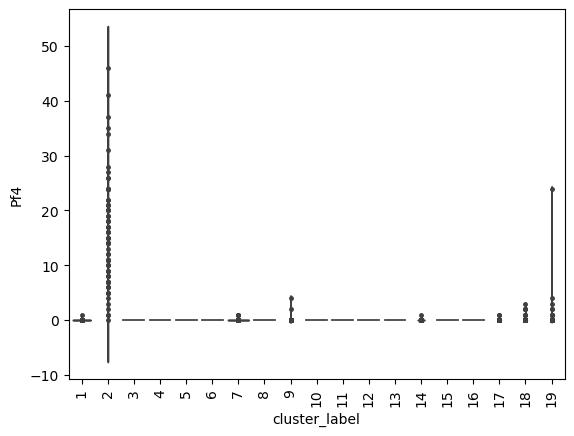

In [26]:
pvm_markers = ['Mrc1','Hexb','Pf4']
%matplotlib inline
for gene in pvm_markers:
    fig,ax = plt.subplots()
    sns.violinplot(x=NN_meta_data_df_plis.T['cluster_label'], y=NN_df_plis.T[gene], inner = 'point')
    #sns.stripplot(x=amy_vglut2_md.T['full_name'], y=amy_vglut2_ce_ge_cv_ls.T[gene], color="k", size=3)
    ax.set_xticklabels(NN_linkage_cluster_order, rotation = 90)
    plt.show()

In [105]:
len(NN_cluster_indices[11])

136

In [132]:
NN_clusters_to_drop, NN_thresh_cells = dp.drop_clusters(NN_meta_data_df_plis, NN_linkage_cluster_order, cluster_labels=[2,3,5,7,13,14,15,16,22,23,24,25,26,27,28,29],cluster_keepers=[], thresh_cells=20)
NN_clusters_to_drop

[2, 3, 5, 7, 13, 14, 15, 16, 22, 23, 24, 25, 26, 27, 28, 29]

In [124]:
len(NN_clusters_to_drop)

15

In [133]:

NN_filtered_folder = '/bigdata/isaac/Nonneuronal_files/filtered/'
NN_df_marker_log_and_std_filtered, NN_df_marker_log_and_std_col_filtered, NN_meta_data_df_plis_filtered, NN_pos_filtered_tmp, NN_df_plis_filtered,NN_linkage_cluster_order_filtered,NN_linkage_cluster_order_filtered_tmp, NN_change_indices_filtered, NN_cluster_indices_filtered  = dp.filter_heatmap_elements(NN_filtered_folder, 'NN', NN_clusters_to_drop,
                                                                                                                                                                                                                                                        NN_df_marker_log_and_std,
                                                                                                                                                                                                                                                        NN_meta_data_df_plis,
                                                                                                                                                                                                                                                        NN_df_plis,
                                                                                                                                                                                                                                                        NN_cluster_indices,
                                                                                                                                                                                                                                                        NN_linkage_cluster_order,
                                                                                                                                                                                                                                                        save_to_file=True)

True
True
Indices where the value changes: [0, 251, 2535, 2681, 4585, 4738, 4797, 4993, 8711, 8918, 8984, 9016, 9100, 10438, 11400, 12359, 12397]
change_indices_filtered [251, 2535, 2681, 4585, 4738, 4797, 4993, 8711, 8918, 8984, 9016, 9100, 10438, 11400, 12359, 12397]
16
{1: 1, 4: 2, 6: 3, 8: 4, 9: 5, 10: 6, 11: 7, 12: 8, 17: 9, 18: 10, 19: 11, 20: 12, 21: 13, 30: 14, 31: 15, 32: 16}
[1 4 6 8 9 10 11 12 17 18 19 20 21 30 31 32]


In [109]:
np.unique(NN_meta_data_df_plis_filtered.loc['cluster_label',:])

array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
       20], dtype=object)

In [110]:
NN_linkage_cluster_order_filtered

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])

In [134]:
Counter(NN_meta_data_df_plis_filtered.loc['cluster_label',:])

Counter({8: 3718,
         2: 2284,
         4: 1904,
         13: 1338,
         14: 962,
         15: 959,
         1: 251,
         9: 207,
         7: 196,
         5: 153,
         3: 146,
         12: 84,
         10: 66,
         6: 59,
         16: 39,
         11: 32})

In [135]:
#merge clusters
NN_clusters_to_merge = [4,5]
NN_filtered_folder = '/bigdata/isaac/Nonneuronal_files/filtered/'
NN_meta_data_df_plis_filtered_merged, NN_linkage_cluster_order_filtered_merged  = dp.merge_heatmap_elements(NN_clusters_to_merge,
                                                                                                            NN_df_marker_log_and_std_filtered,
                                                                                                            NN_meta_data_df_plis_filtered,
                                                                                                            NN_df_plis_filtered ,
                                                                                                            NN_linkage_cluster_order_filtered) 

merge
[ 1  2  3  4  6  7  8  9 10 11 12 13 14 15 16]
True
True
Indices where the value changes: [0, 251, 2535, 2681, 4738, 4797, 4993, 8711, 8918, 8984, 9016, 9100, 10438, 11400, 12359, 12397]
change_indices_filtered [251, 2535, 2681, 4738, 4797, 4993, 8711, 8918, 8984, 9016, 9100, 10438, 11400, 12359, 12397]
15
{1: 1, 2: 2, 3: 3, 4: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9, 11: 10, 12: 11, 13: 12, 14: 13, 15: 14, 16: 15}
[1 2 3 4 6 7 8 9 10 11 12 13 14 15 16]


In [225]:
NN_meta_data_df_plis_filtered_merged.loc[:,NN_meta_data_df_plis_filtered_merged.loc['cluster_label',:]==2].shape[1]

787

## 3) run rc (recalc) to get filtered df marker, tsne arr

It contains 0 infinite values


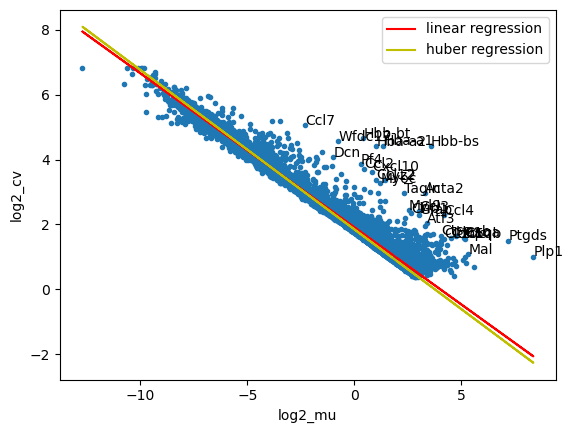

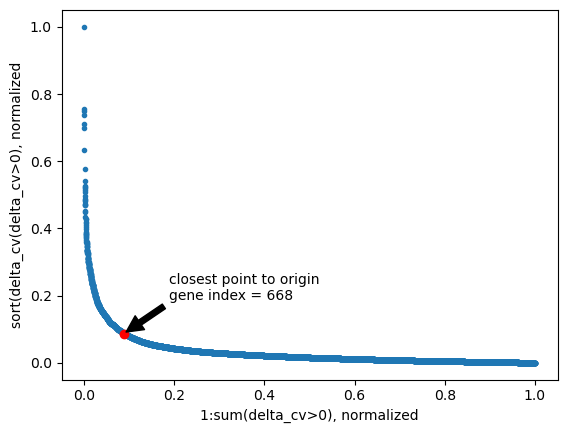

(668, 12598)
True
It contains 0 infinite values
#nan values 0
column (gene) mean after standardization: 0.00
column (gene) sigma after standardization: 1.00


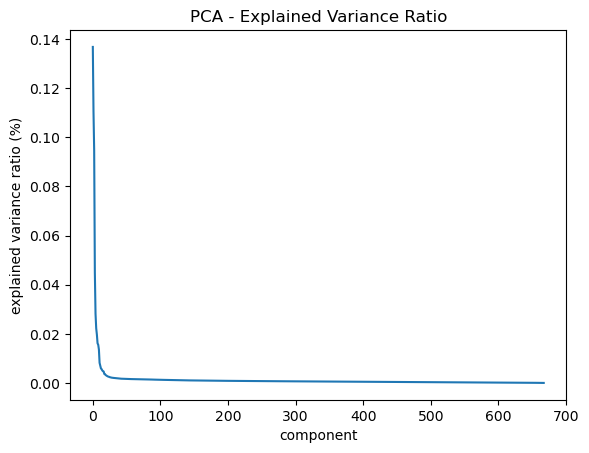

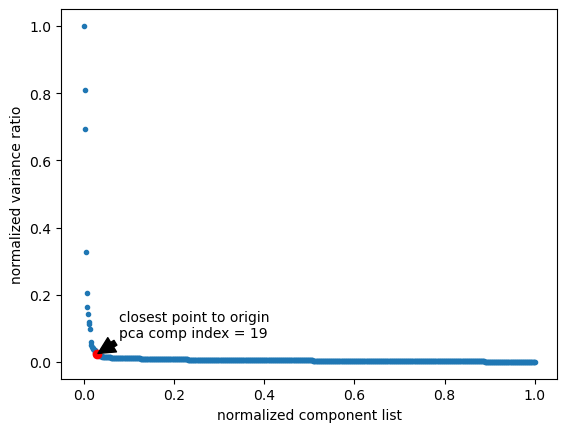

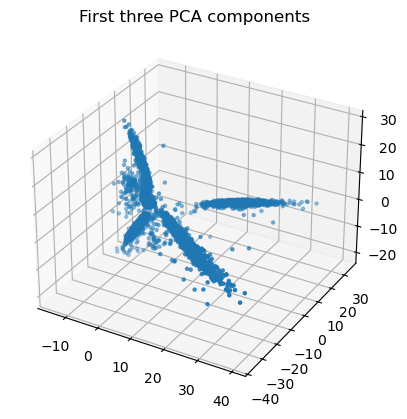

2025-04-14 17:28:26,924 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-04-14 17:28:28,126 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-04-14 17:28:28,166 - harmonypy - INFO - Iteration 1 of 20
2025-04-14 17:28:30,815 - harmonypy - INFO - Iteration 2 of 20
2025-04-14 17:28:32,945 - harmonypy - INFO - Iteration 3 of 20
2025-04-14 17:28:33,779 - harmonypy - INFO - Iteration 4 of 20
2025-04-14 17:28:34,732 - harmonypy - INFO - Iteration 5 of 20
2025-04-14 17:28:35,566 - harmonypy - INFO - Converged after 5 iterations


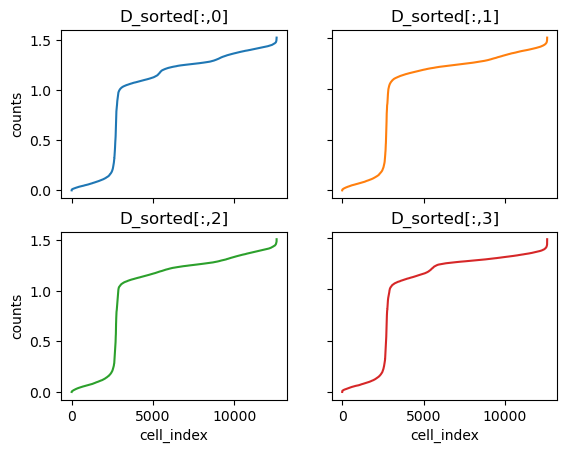

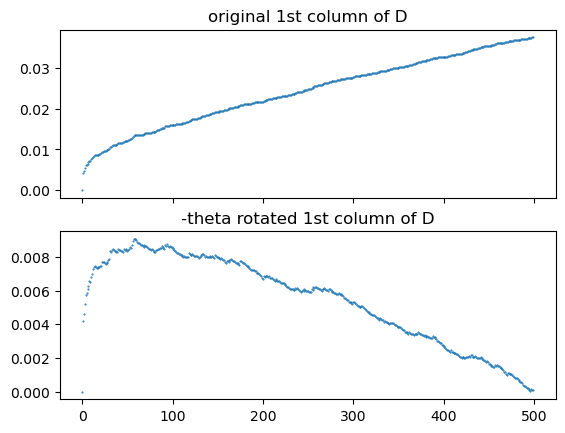

creating tsne object with the following parameters: 
n_components:2
n_iter: 1000
learning_rate: 50
early_exaggeration: 5
init: pca
perplexity: 100


/home/isaac/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


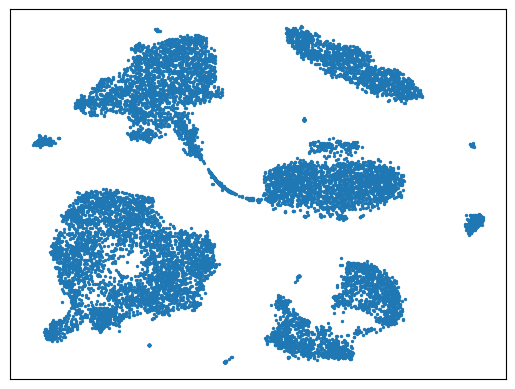

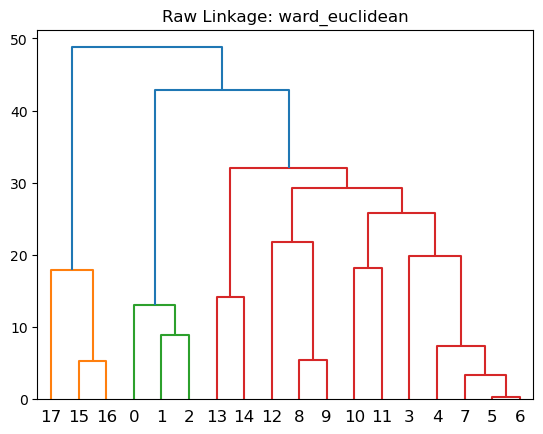

[17 16 15 14 13 10 11  7  6  5  4  3  9  8 12  2  1  0]


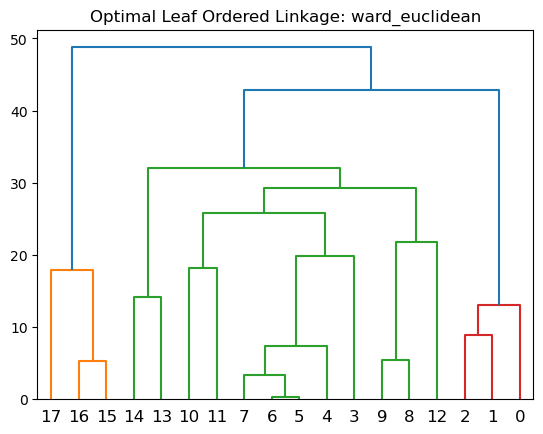

metadata df shape post inter cluster sort
(29, 12598)


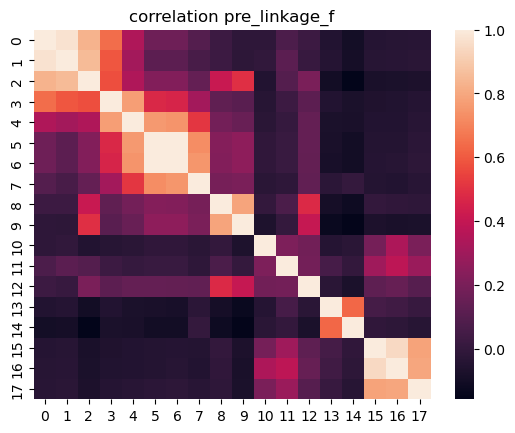

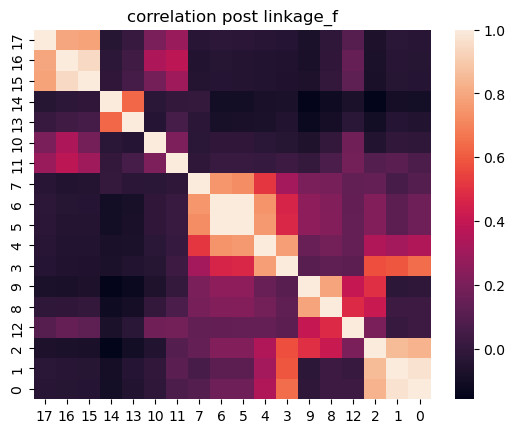

{18: 1, 17: 2, 16: 3, 15: 4, 14: 5, 11: 6, 12: 7, 8: 8, 7: 9, 6: 10, 5: 11, 4: 12, 10: 13, 9: 14, 13: 15, 3: 16, 2: 17, 1: 18}
[1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18]
len marker_Genes_sorted 121
len marker_genes_sorted_final 121
column (gene) mean after standardization: 0.00
column (gene) sigma after standardization: 1.00
Indices where the value changes: [0, 39, 998, 1960, 3298, 3382, 3589, 3655, 3714, 3867, 5771, 5821, 5967, 9685, 9881, 9913, 10063, 12347, 12597]
[0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17]
16
[array([ 0, 12, 13,  1, 16, 18, 19, 15,  5,  4,  3,  2]), array([11, 10, 17,  9, 14,  8,  7,  6]), array([22, 21, 20, 23, 27, 26, 29, 28, 24, 25]), array([31, 30, 35, 32, 34, 33, 37, 36, 38]), array([43, 39, 41, 40, 45, 44, 42]), array([ 47, 111,  48,  49,  50,  51,  52,  53,  46]), array([54, 62, 60, 59, 58, 57, 56, 55]), array([61, 64, 63, 67]), array([65]), array([69, 66, 68]), array([76, 75, 74, 77, 73, 72, 71, 70]), array([82, 83, 79, 81, 78]), array([84, 

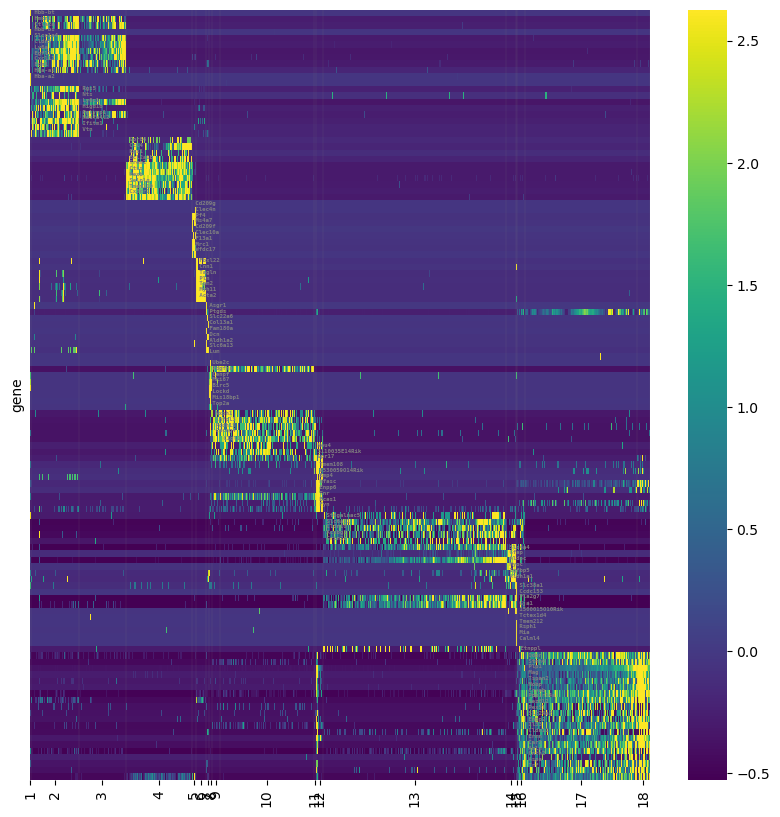

writing to file


In [118]:
NN_filtered_folder = '/bigdata/isaac/Nonneuronal_files/filtered/'
cell_class = 'Nonneuronal'
%matplotlib inline
NN_df_marker_f, NN_arr_tsne_f, NN_meta_data_df_plis_f, NN_meta_data_df_pca, NN_mgs_f, NN_ind_f, NN_ind_s_f, NN_df_marker_log_and_std_col_f, NN_pos_f, NN_linkage_cluster_order_filtered, NN_change_indices_f = dp_rc.reprocess(NN_df_ge,NN_meta_data_df_plis_filtered,NN_linkage_cluster_order_filtered,NN_filtered_folder,cell_class, sort = True, write_to_file=True)

In [120]:
Counter(NN_meta_data_df_plis_f.loc['cluster_label',:])

Counter({13: 3718,
         17: 2284,
         10: 1904,
         4: 1338,
         3: 962,
         2: 959,
         18: 251,
         6: 207,
         14: 196,
         9: 153,
         16: 150,
         12: 146,
         5: 84,
         7: 66,
         8: 59,
         11: 50,
         1: 39,
         15: 32})

[0, 2, 3, 4, 5, 6, 7, 8, 9, 10]
10
[array([ 0,  1,  2,  3,  4,  5,  6, 15,  9, 10, 11, 12, 13, 14,  8,  7]), array([24, 25, 18, 19, 20, 21, 22, 23, 16, 17]), array([26, 27, 28, 29, 30, 31, 33, 34, 32]), array([39, 35, 38, 37, 36, 44, 45, 42, 43, 41, 40]), array([51, 50, 49, 52, 48, 46]), array([47, 54, 58, 57, 56, 59, 55, 53]), array([60, 62, 63, 64, 65, 61]), array([73]), array([79, 67, 66, 69, 68, 70, 77, 71, 76, 81, 80, 75, 78]), array([82, 86, 83, 85, 84, 74, 72])]
10
saving heatmap..


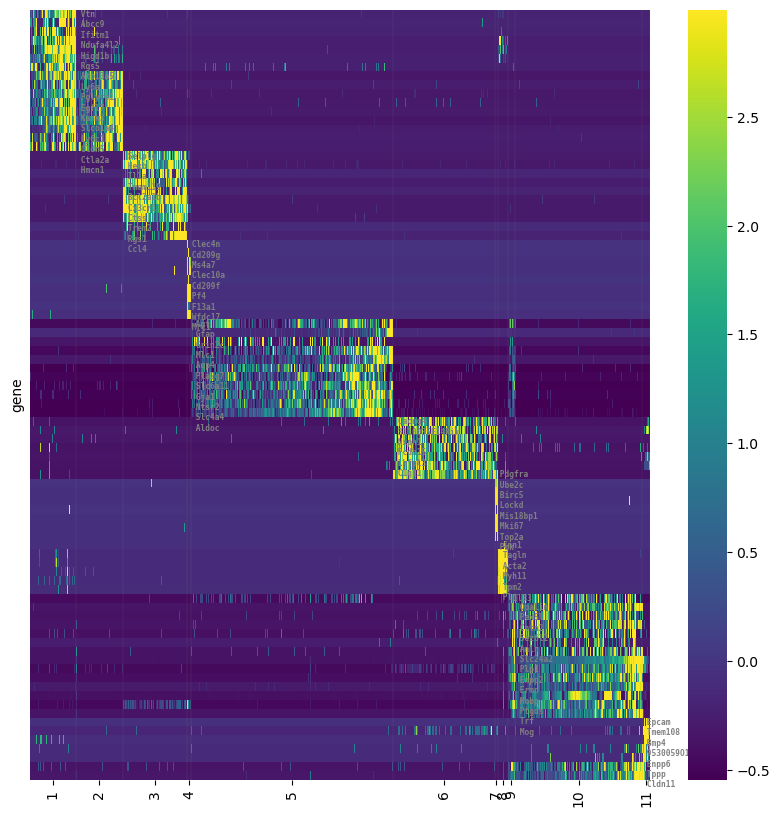

In [101]:
linkage_alg = 'ward'
dist_metric = 'euclidean'
NN_tg_f, NN_tgfs_f = dp.get_heatmap_labels(NN_mgs_f, NN_ind_f, NN_ind_s_f)
dp.plot_marker_heatmap(NN_df_marker_log_and_std_col_f, 
                    NN_pos_f, 
                    NN_linkage_cluster_order_filtered, 
                    NN_change_indices_f, 
                    NN_tg_f, 
                    NN_tgfs_f, 
                    linkage_alg,
                    dist_metric,
                    '/bigdata/isaac/tmp/',
                    fs_waterfall = 5.65,
                    savefig = True,
                    cell_class = str(cell_class)+'_filtered_tg_reenrich_reproc')

### L3 recalc with filtered merged data

It contains 0 infinite values


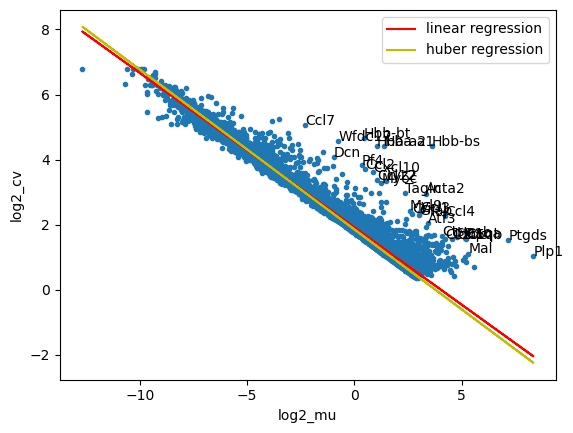

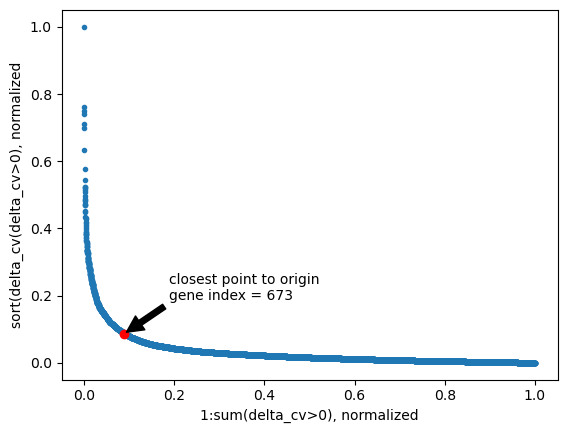

(673, 12398)
True
It contains 0 infinite values
#nan values 0
column (gene) mean after standardization: 0.00
column (gene) sigma after standardization: 1.00


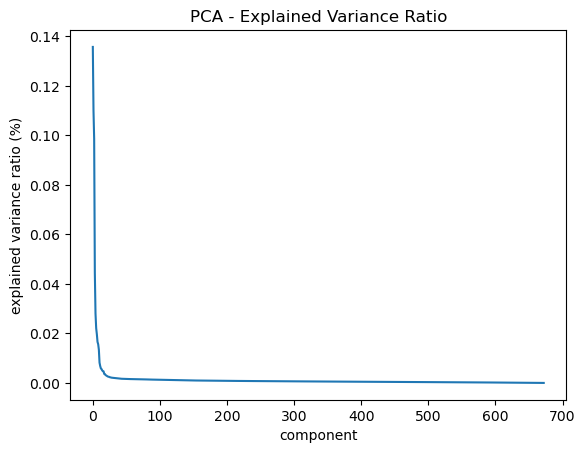

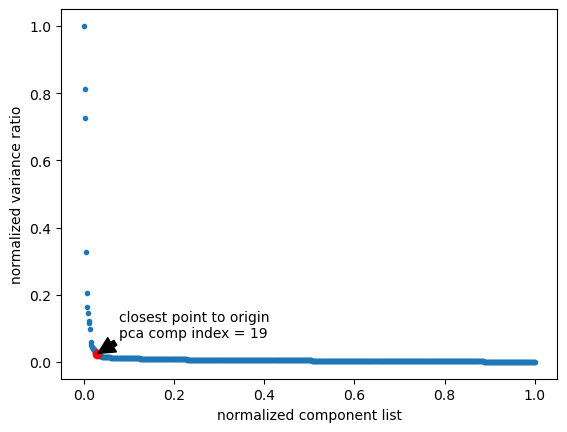

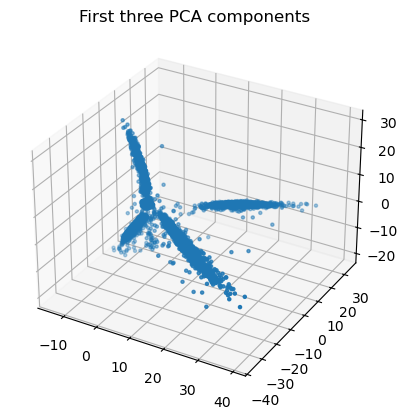

2025-04-14 18:08:19,704 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-04-14 18:08:20,928 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-04-14 18:08:20,966 - harmonypy - INFO - Iteration 1 of 20
2025-04-14 18:08:23,487 - harmonypy - INFO - Iteration 2 of 20
2025-04-14 18:08:25,982 - harmonypy - INFO - Iteration 3 of 20
2025-04-14 18:08:26,807 - harmonypy - INFO - Iteration 4 of 20
2025-04-14 18:08:27,623 - harmonypy - INFO - Iteration 5 of 20
2025-04-14 18:08:28,444 - harmonypy - INFO - Converged after 5 iterations


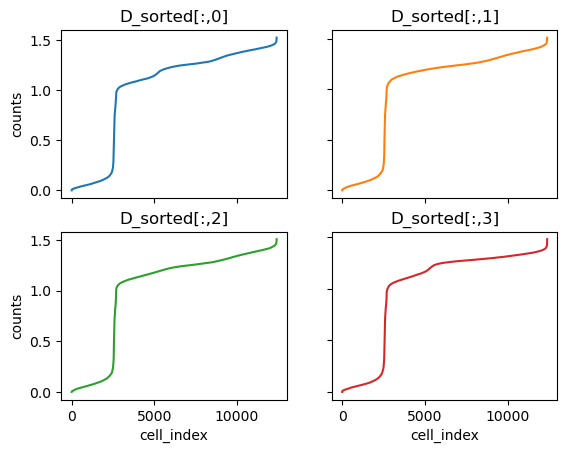

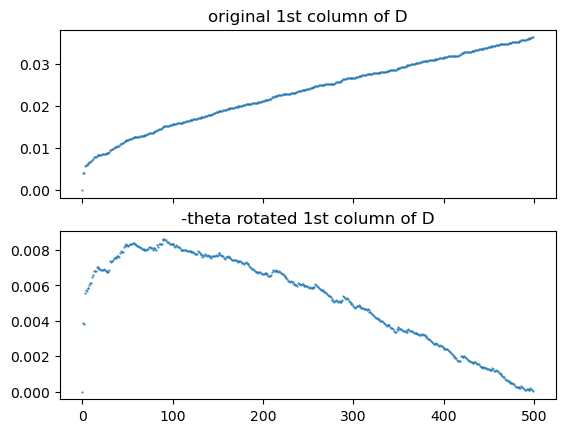

creating tsne object with the following parameters: 
n_components:2
n_iter: 1000
learning_rate: 50
early_exaggeration: 5
init: pca
perplexity: 100


/home/isaac/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


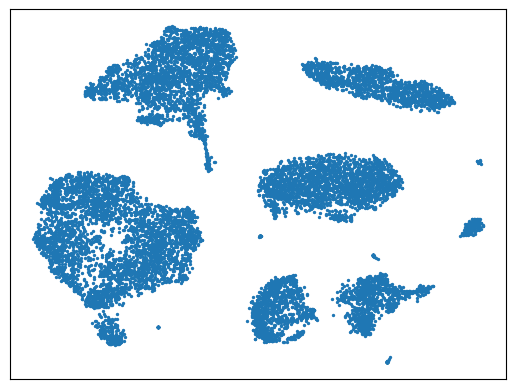

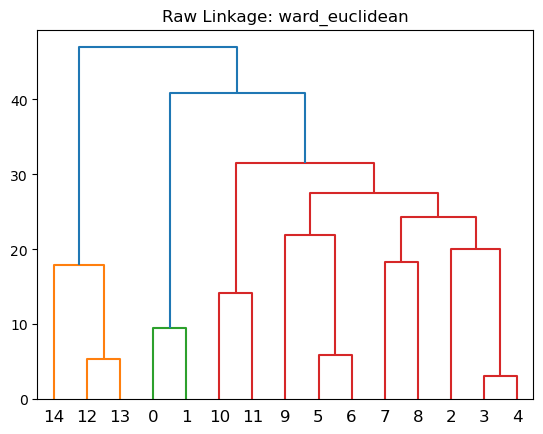

[14 13 12 11 10  7  8  4  3  2  6  5  9  1  0]


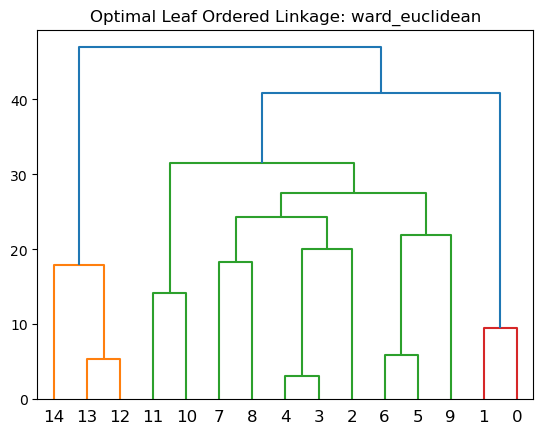

metadata df shape post inter cluster sort
(29, 12398)


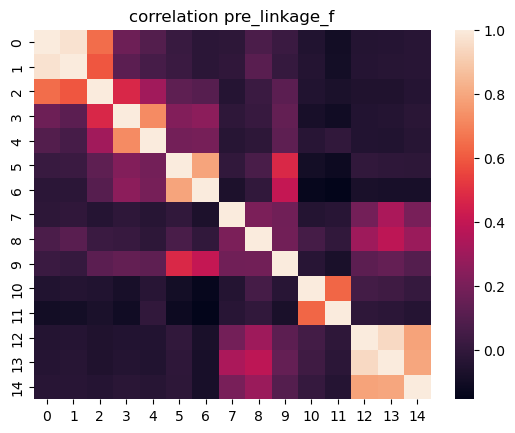

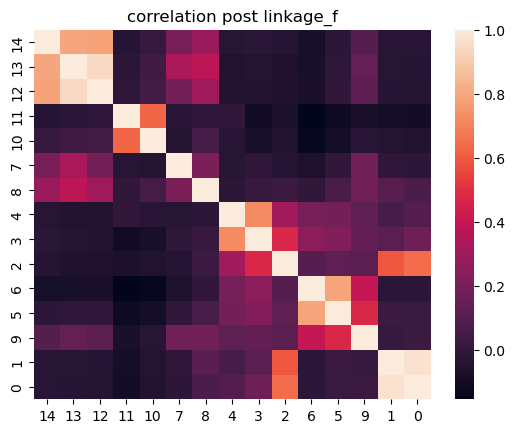

{15: 1, 14: 2, 13: 3, 12: 4, 11: 5, 8: 6, 9: 7, 5: 8, 4: 9, 3: 10, 7: 11, 6: 12, 10: 13, 2: 14, 1: 15}
[1 2 3 4 5 6 7 8 9 10 11 12 13 14 15]
len marker_Genes_sorted 107
len marker_genes_sorted_final 107
column (gene) mean after standardization: 0.00
column (gene) sigma after standardization: 1.00
Indices where the value changes: [0, 39, 998, 1960, 3298, 3382, 3589, 3655, 3714, 5771, 5917, 9635, 9831, 9863, 12147, 12397]
[0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14]
13
[array([ 0,  1,  2, 12, 15, 13, 18, 16, 19,  3,  5,  4]), array([ 8, 11, 14, 17,  7,  6,  9, 10]), array([28, 29, 22, 23, 24, 25, 26, 27, 20, 21]), array([30, 31, 35, 38, 37, 36, 33, 34, 32]), array([39, 40, 41, 42, 43, 44, 45]), array([46, 47, 97, 50, 53, 52, 51, 48, 49]), array([54, 55, 62, 60, 59, 57, 56, 58]), array([67, 64, 65, 66, 63, 61]), array([72, 70, 68, 71, 69]), array([75, 76, 77, 74, 73]), array([86, 85, 82, 83, 78, 79]), array([81, 80, 92, 93, 91, 84, 87, 88, 89, 90]), array([106, 105, 104, 103, 102, 101, 100

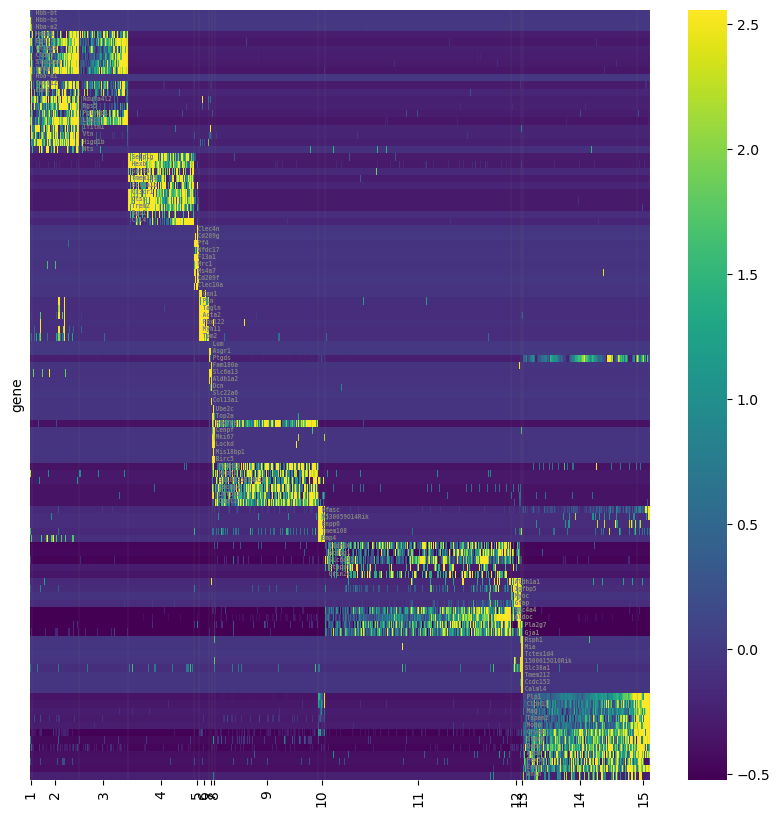

writing to file


In [136]:
NN_filtered_folder = '/bigdata/isaac/Nonneuronal_files/filtered_merged/'
cell_class = 'Nonneuronal'
%matplotlib inline
NN_df_marker_fm, NN_arr_tsne_fm, NN_meta_data_df_plis_fm, NN_meta_data_df_pca_m, NN_mgs_fm, NN_ind_fm, NN_ind_s_fm, NN_df_marker_log_and_std_col_fm, NN_pos_fm, NN_linkage_cluster_order_filtered_merged, NN_change_indices_fm = dp_rc.reprocess(NN_df_ge,
                                                                                                                                                                                                                                         NN_meta_data_df_plis_filtered_merged,
                                                                                                                                                                                                                                         NN_linkage_cluster_order_filtered_merged,
                                                                                                                                                                                                                                         NN_filtered_folder,
                                                                                                                                                                                                                                         cell_class, 
                                                                                                                                                                                                                                         sort = True, 
                                                                                                                                                                                                                                         write_to_file=True)

In [130]:
Counter(NN_meta_data_df_plis_fm.loc['cluster_label'])

Counter({11: 3718,
         15: 2284,
         9: 2057,
         4: 1338,
         3: 962,
         2: 959,
         16: 251,
         6: 207,
         12: 196,
         14: 150,
         10: 146,
         5: 84,
         7: 66,
         8: 59,
         1: 39,
         13: 32})

In [202]:
np.all(NN_meta_data_df_plis_filtered_merged.columns == NN_meta_data_df_plis_fm.columns)

False

In [137]:
NN_df_plis_fm = NN_df_plis_filtered.reindex(columns = NN_df_marker_fm.columns)

/tmp/ipykernel_3357189/1061327691.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(NN_linkage_cluster_order_filtered_merged, rotation = 90)


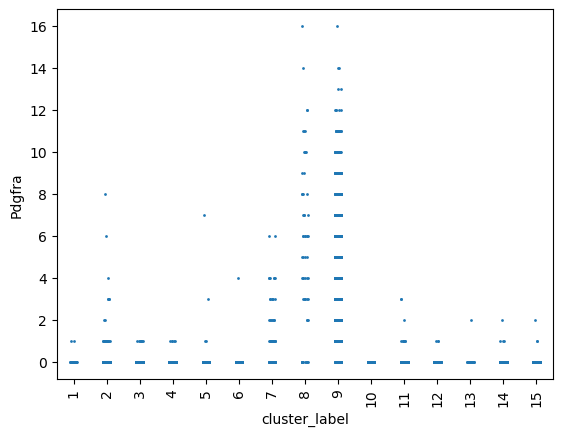

In [188]:
#check some specific expression of genes
gene = 'Pdgfra'
%matplotlib inline
fig,ax = plt.subplots()
#sns.violinplot(x=NN_meta_data_df_plis.T['cluster_label'], y=NN_df_n.T[gene], inner = 'point')
#sns.objects.jitter(width = 0.5, x=NN_meta_data_df_plis.T['cluster_label'], y=NN_df_n.T[gene])
sns.stripplot(x=NN_meta_data_df_plis_fm.T['cluster_label'], y=NN_df_plis_fm.T[gene], jitter = True, size = 2)
ax.set_xticklabels(NN_linkage_cluster_order_filtered_merged, rotation = 90)
plt.show()

/tmp/ipykernel_1329735/2224410124.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(NN_linkage_cluster_order, rotation = 90)


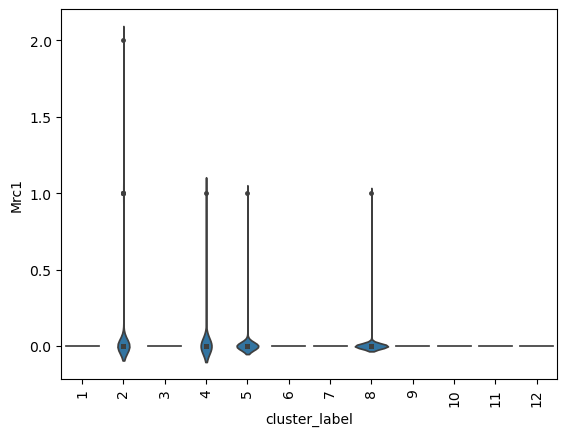

/tmp/ipykernel_1329735/2224410124.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(NN_linkage_cluster_order, rotation = 90)


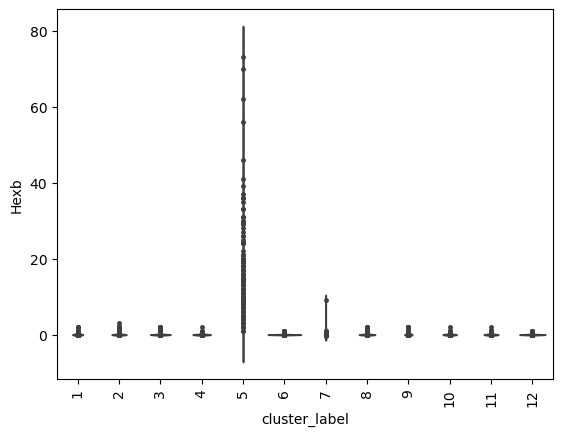

/tmp/ipykernel_1329735/2224410124.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(NN_linkage_cluster_order, rotation = 90)


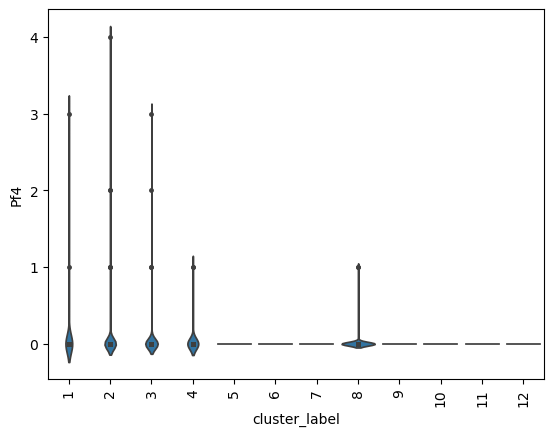

In [123]:
pvm_markers = ['Mrc1','Hexb','Pf4']
%matplotlib inline
for gene in pvm_markers:
    fig,ax = plt.subplots()
    sns.violinplot(x=NN_meta_data_df_plis_fm.T['cluster_label'], y=NN_df_plis_fm.T[gene], inner = 'point')
    #sns.stripplot(x=amy_vglut2_md.T['full_name'], y=amy_vglut2_ce_ge_cv_ls.T[gene], color="k", size=3)
    ax.set_xticklabels(NN_linkage_cluster_order, rotation = 90)
    plt.show()

## 4) Add cluster labels (manual)

In [186]:

NN_filtered_folder = '/bigdata/isaac/Nonneuronal_files/filtered_merged/'
NN_labels = dp.get_cluster_labels(NN_filtered_folder, 'Nonneuronal_filtered_labels_rc.csv')
NN_labels

['Erythrocyte',
 'Pericyte',
 'Endothelial',
 'Microglia',
 'PVM',
 'VSM',
 'Fibroblast',
 'Proliferating_cells',
 'OPC_1',
 'OPC_2',
 'Astro',
 'Astro_gfap',
 'Epend',
 'OL_1',
 'OL_2']

### add label markers to plis filtered metadata

In [172]:
NN_linkage_cluster_order_filtered_merged

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

In [189]:
NN_filtered_folder = '/bigdata/isaac/Nonneuronal_files/filtered_merged/'
NN_meta_data_df_plis_fm_markers = dp.update_metadata_w_markers(NN_filtered_folder, 
                                                                         NN_meta_data_df_plis_fm,
                                                                         NN_linkage_cluster_order_filtered_merged,
                                                                         NN_labels,
                                                                         'NN',
                                                                        write_to_file = True)


In [190]:
len(NN_tg_f)

13

[0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14]
13
[array([ 0,  1,  2, 12, 15, 13, 18, 16, 19,  3,  5,  4]), array([ 8, 11, 14, 17,  7,  6,  9, 10]), array([28, 29, 22, 23, 24, 25, 26, 27, 20, 21]), array([30, 31, 35, 38, 37, 36, 33, 34, 32]), array([39, 40, 41, 42, 43, 44, 45]), array([46, 47, 97, 50, 53, 52, 51, 48, 49]), array([54, 55, 62, 60, 59, 57, 56, 58]), array([67, 64, 65, 66, 63, 61]), array([72, 70, 68, 71, 69]), array([75, 76, 77, 74, 73]), array([86, 85, 82, 83, 78, 79]), array([81, 80, 92, 93, 91, 84, 87, 88, 89, 90]), array([106, 105, 104, 103, 102, 101, 100,  99,  98,  96,  95,  94])]
13
saving heatmap..


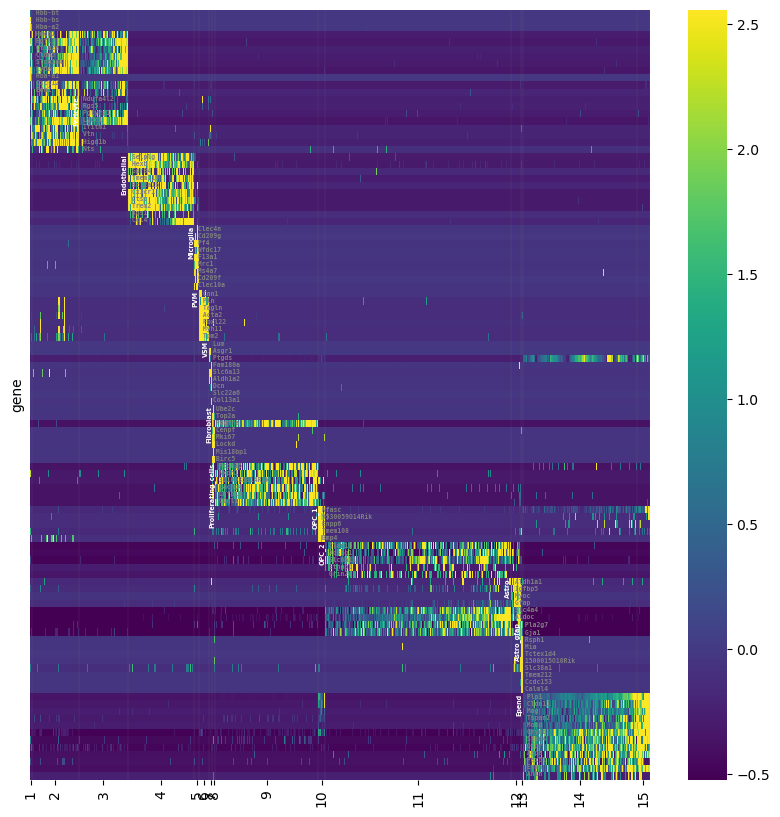

In [191]:
#plot heatmap w/ labels
NN_filtered_folder = '/bigdata/isaac/Nonneuronal_files/filtered_merged/'
%matplotlib inline
linkage_alg = 'ward'
dist_metric = 'euclidean'
NN_tg_f, NN_tgfs_f = dp.get_heatmap_labels(NN_mgs_fm, NN_ind_fm, NN_ind_s_fm)
#sanity check - plotting only filtered gaba_df (clusters removed)
dp.plot_marker_heatmap(NN_df_marker_log_and_std_col_fm, 
                       NN_pos_fm, 
                       NN_linkage_cluster_order_filtered_merged, 
                       NN_change_indices_fm, 
                       NN_tg_f, 
                       NN_tgfs_f, 
                       linkage_alg,
                       dist_metric,
                       NN_filtered_folder,
                       fs_waterfall = 4.6,
                       cluster_labels = NN_labels,
                       savefig = True,
                       cell_class = 'NN_filtered_merged_tg_reenrich_labeled')

In [193]:
NN_filtered_folder

'/bigdata/isaac/Nonneuronal_files/filtered_merged/'

In [198]:
#generate colormap
np.all(NN_meta_data_df_plis_fm.columns == NN_meta_data_df_plis_fm_markers.columns)

True

In [199]:
NN_meta_data_df_plis_fm.shape

(29, 12398)

In [196]:
NN_arr_tsne_fm.shape

(12398, 2)

In [179]:
NN_df_marker_log_and_std_col_fm.shape

(107, 12398)

In [178]:
NN_meta_data_df_plis_fm_markers.shape

(31, 12398)

In [192]:
Counter(NN_meta_data_df_plis_fm_markers.loc['markers',:])

Counter({'Astro': 3718,
         'OL_1': 2284,
         'OPC_1': 2057,
         'Microglia': 1338,
         'Endothelial': 962,
         'Pericyte': 959,
         'OL_2': 251,
         'VSM': 207,
         'Astro_gfap': 196,
         'OPC_2': 146,
         'PVM': 84,
         'Fibroblast': 66,
         'Proliferating_cells': 59,
         'Erythrocyte': 39,
         'Epend': 32})

In [195]:
np.all(NN_meta_data_df_plis_filtered.columns == NN_meta_data_df_plis_filtered_merged.columns)

True

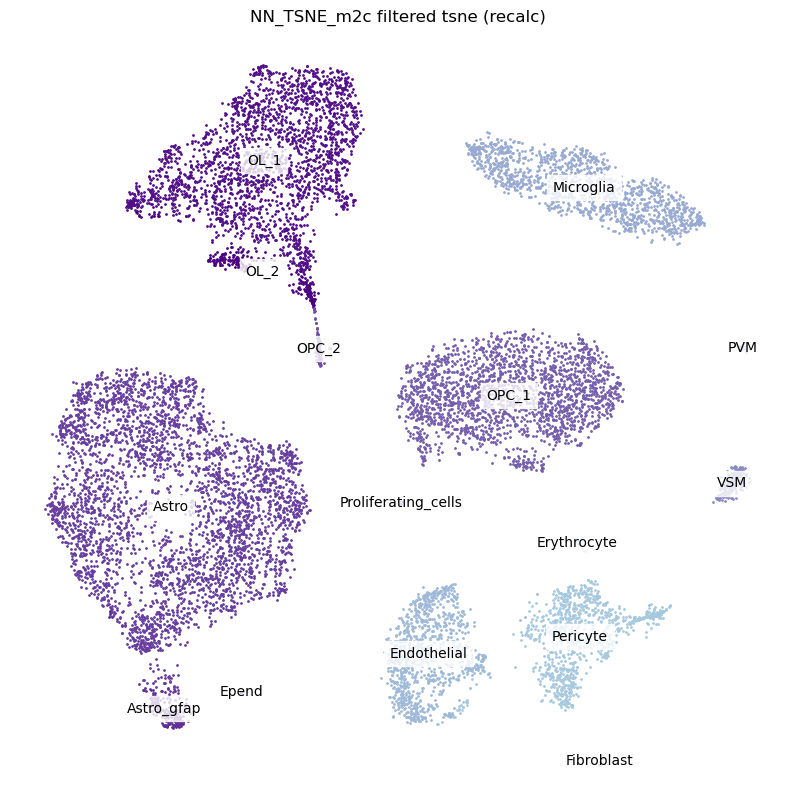

In [209]:
NN_label_color_df = pd.read_csv(NN_filtered_folder + 'Nonneuronal_filtered_labels_rc.csv')
NN_m_2_c_dict = dict(zip(NN_label_color_df.loc[:,'markers'],NN_label_color_df.loc[:,'hex']))

#NN_meta_data_df_plis_filtered_tsne = dp.update_metadata_w_markers(folder, NN_meta_data_df_plis_filtered, NN_linkage_cluster_order_filtered, NN_labels, 'NN_TSNE', write_to_file = False)
#resort tsne index to match index of final labeled metadata
NN_tsne_arr_tmp = pd.DataFrame(index=NN_meta_data_df_plis_filtered_merged.columns, data=NN_arr_tsne_fm)
NN_tsne_arr_tmp_ri = NN_tsne_arr_tmp.reindex(index = NN_meta_data_df_plis_fm_markers.columns)

dp.plot_rc_tsne(NN_meta_data_df_plis_fm_markers,NN_tsne_arr_tmp_ri.values,'NN_TSNE_m2c', NN_filtered_folder,m_2_c_dict=NN_m_2_c_dict,savefig=True)


In [211]:
NN_tsne_arr_tmp_ri

,0,1
GATCCCTCAATACGCT-1_10X38_2,23.022240,-14.208116
TGATGGTCACAAGCCC-1_10X37_1,23.018860,-14.192239
GGGTGAATCAAACGTC-1_10X38_1,23.027048,-14.216194
TAACGACAGGATCACG-1_10X37_1,23.036201,-14.233644
AGCGTATTCCGCAACG-1_10X38_2,22.994909,-14.170358
...,...,...
GAGAGGTCACATCATG-1_10X37_2,-6.940832,12.564197
ATCAGGTTCCACTAGA-1_10X35_2,-5.201704,11.441384
TCCACGTAGAGCATCG-1_10X37_1,-5.398714,11.834961
CTGCGAGCACTACGGC-1_10X35_2,-5.325629,11.607701


In [4]:
tmp = np.load('/bigdata/isaac/Nonneuronal_files/filtered_merged/NN_TSNE_m2c_arr_tsne_f_2025-04-15.npy', allow_pickle=True)
tmp

array([[ 23.02224  , -14.208116 ],
       [ 23.01886  , -14.192239 ],
       [ 23.027048 , -14.216194 ],
       ...,
       [ -5.3987136,  11.834961 ],
       [ -5.3256288,  11.607701 ],
       [ -5.148271 ,  11.095882 ]], dtype=float32)

In [6]:
metadata_tmp = pd.read_json('/bigdata/isaac/Nonneuronal_files/filtered_merged/NNmeta_data_df_plis_f_markers_2025-04-14.json')
metadata_tmp

,GATCCCTCAATACGCT-1_10X38_2,TGATGGTCACAAGCCC-1_10X37_1,GGGTGAATCAAACGTC-1_10X38_1,TAACGACAGGATCACG-1_10X37_1,AGCGTATTCCGCAACG-1_10X38_2,GCAGGCTCACTCCTGT-1_10X38_2,ATGATCGGTCTGTCCT-1_10X38_2,TGATTCTAGTTTCGGT-1_10X38_1,AATAGAGGTTCATCGA-1_10X37_1,CATCGTCCAGTTACCA-1_10X51_2,...,GCACGTGGTTATTCCT-1_10X37_1,CAAGAGGGTCAATCTG-1_10X36_2,GGTGTCGAGAAGCTGC-1_10X36_2,AAGCCATGTGGATGAC-1_10X35_1,TTCTTCCCAAGACCTT-1_10X35_1,GAGAGGTCACATCATG-1_10X37_2,ATCAGGTTCCACTAGA-1_10X35_2,TCCACGTAGAGCATCG-1_10X37_1,CTGCGAGCACTACGGC-1_10X35_2,CTCTGGTTCGAAGCAG-1_10X37_1
Serial_Number,70.0,67.0,69.0,67.0,70.0,70.0,70.0,69.0,67.0,98.0,...,67.0,66.0,66.0,63.0,63.0,68.0,64.0,67.0,64.0,67.0
Date_Captured,2019-12-01,2019-11-25,2019-12-01,2019-11-25,2019-12-01,2019-12-01,2019-12-01,2019-12-01,2019-11-25,05/31/20,...,2019-11-25,2019-11-24,2019-11-24,2019-11-20,2019-11-20,2019-11-25,2019-11-20,2019-11-25,2019-11-20,2019-11-25
Species,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,...,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm
Transcriptome,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,...,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10
Strain,,,,,,,,,,C57Bl/6,...,,,,,,,,,,
Project,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,...,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph
Group,Naïve-F,Naïve-M,Naïve-F,Naïve-M,Naïve-F,Naïve-F,Naïve-F,Naïve-F,Naïve-M,Breeder-F,...,Naïve-M,Naïve-M,Naïve-M,Naïve-F,Naïve-F,Naïve-M,Naïve-F,Naïve-M,Naïve-F,Naïve-M
ChipID,10X38,10X37,10X38,10X37,10X38,10X38,10X38,10X38,10X37,10X51,...,10X37,10X36,10X36,10X35,10X35,10X37,10X35,10X37,10X35,10X37
SampleID,10X38_2,10X37_1,10X38_1,10X37_1,10X38_2,10X38_2,10X38_2,10X38_1,10X37_1,10X51_2,...,10X37_1,10X36_2,10X36_2,10X35_1,10X35_1,10X37_2,10X35_2,10X37_1,10X35_2,10X37_1
DonorID,DI6,"DI4,DI5",DI6,"DI4,DI5",DI6,DI6,DI6,DI6,"DI4,DI5",DI-B1-F,...,"DI4,DI5",DI3,DI3,"DI1,DI2","DI1,DI2","DI4,DI5","DI1,DI2","DI4,DI5","DI1,DI2","DI4,DI5"


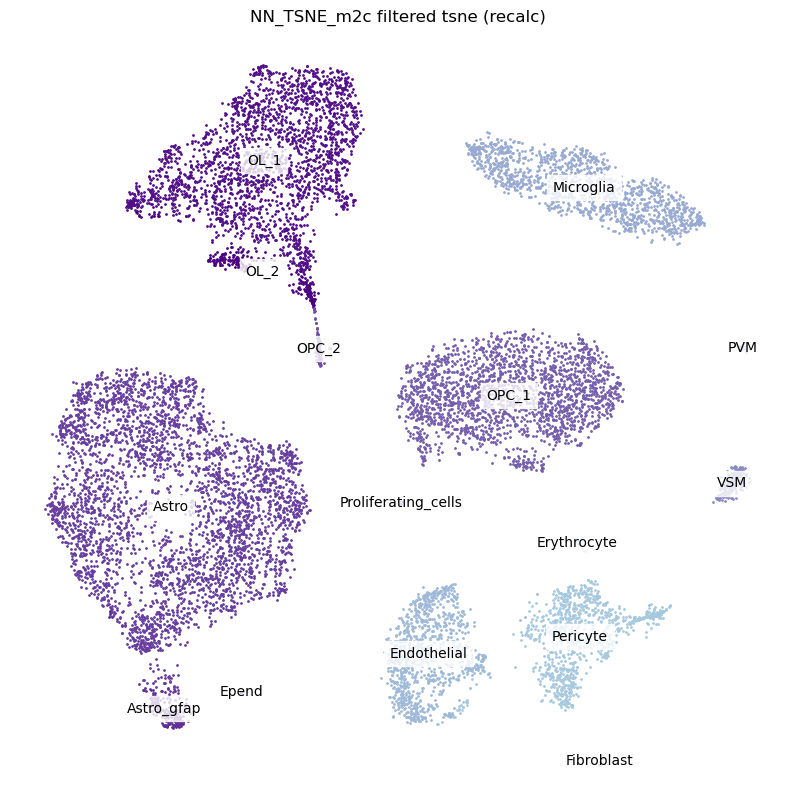

In [9]:
%matplotlib inline
NN_filtered_folder = '/bigdata/isaac/Nonneuronal_files/filtered_merged/'
NN_label_color_df = pd.read_csv(NN_filtered_folder + 'Nonneuronal_filtered_labels_rc.csv')
NN_m_2_c_dict = dict(zip(NN_label_color_df.loc[:,'markers'],NN_label_color_df.loc[:,'hex']))

dp.plot_rc_tsne(metadata_tmp,tmp,'NN_TSNE_m2c', NN_filtered_folder,m_2_c_dict=NN_m_2_c_dict,savefig=False)

In [10]:
NN_m_2_c_dict

{'Erythrocyte': '#ADD8E6',
 'Pericyte': '#A6C9DF',
 'Endothelial': '#9FB9D8',
 'Microglia': '#98AAD1',
 'PVM': '#919AC9',
 'VSM': '#8A8BC2',
 'Fibroblast': '#837BBB',
 'Proliferating_cells': '#7C6CB4',
 'OPC_1': '#755DAD',
 'OPC_2': '#6E4DA6',
 'Astro': '#673E9F',
 'Astro_gfap': '#602E97',
 'Epend': '#591F90',
 'OL_1': '#520F89',
 'OL_2': '#4B0082'}

In [11]:
NN_g_2_c_dict = {'Breeder-F':'blue','Breeder-M':'orange','Naïve-F':'green','Naïve-M':'red'}
NN_g_2_c_dict

{'Breeder-F': 'blue',
 'Breeder-M': 'orange',
 'Naïve-F': 'green',
 'Naïve-M': 'red'}

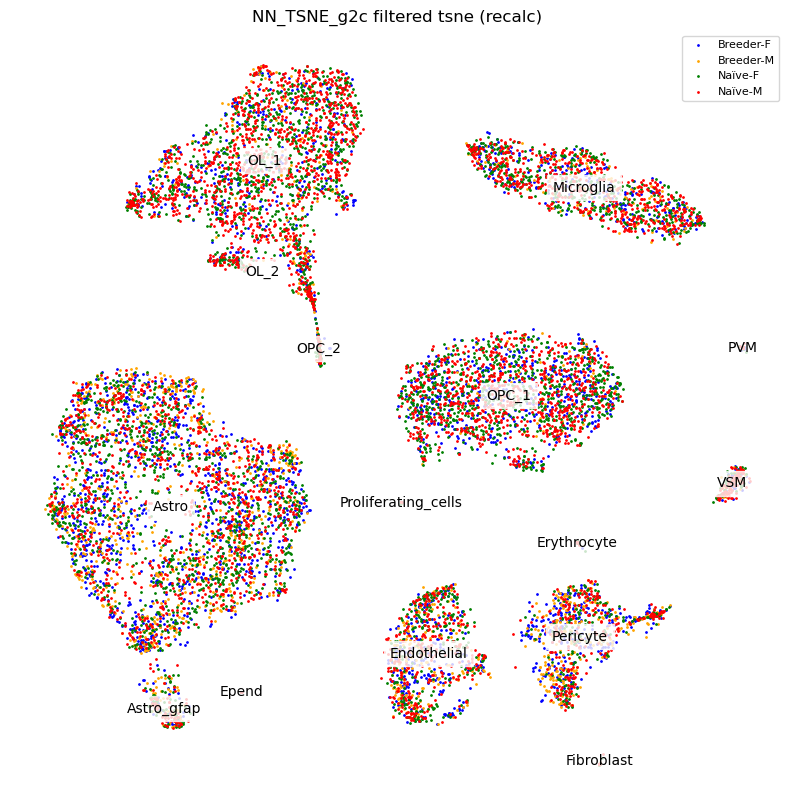

In [15]:
dp.plot_rc_tsne_group(metadata_tmp,tmp,'NN_TSNE_g2c', NN_filtered_folder,m_2_c_dict=NN_g_2_c_dict,savefig=True)

gene in df?  True
gene index:  [155]


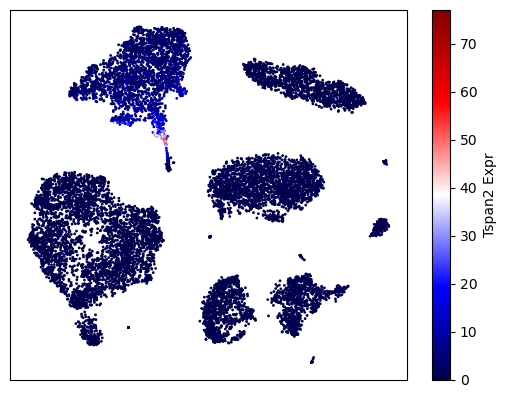

In [217]:
gene = 'Tspan2'
print('gene in df? ', gene in NN_df_plis_fm.index)
print ('gene index: ', np.where(NN_df_plis_fm.index == gene)[0])

x = NN_tsne_arr_tmp_ri.iloc[:, 0]
y = NN_tsne_arr_tmp_ri.iloc[:, 1]
z = np.array(NN_df_plis_fm.loc[gene,:])

#visualise tsne
fig, ax = plt.subplots()
scatter = ax.scatter(x, y, c = z , cmap = 'seismic' , s = 1)

# Create colorbar
sm = ScalarMappable(cmap='seismic')
sm.set_array(z)
# Create colorbar
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label(gene + ' Expr')

plt.xticks([])
plt.yticks([])

plt.show()

In [218]:
NN_adata_f = ad.AnnData(NN_df_marker_fm.T)
#or use full gene list to get
#add aligned metadata
for x in NN_meta_data_df_plis_fm_markers.index:
    NN_adata_f.obs[str(x)] = NN_meta_data_df_plis_fm_markers.loc[str(x),:]

NN_markers = NN_adata_f.obs['markers']
_, idx = np.unique(NN_adata_f.obs['markers'], return_index=True)
NN_markers = list(NN_markers[np.sort(idx)])
NN_violin_markers = ['Hbb-bs','Cldn5','Hexb','Mrc1','Acta2','Lum','Pdgfra','Nfasc','Aldoc','Gfap','Calml4','Tspan2']

/tmp/ipykernel_3357189/1269872343.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  NN_markers = list(NN_markers[np.sort(idx)])


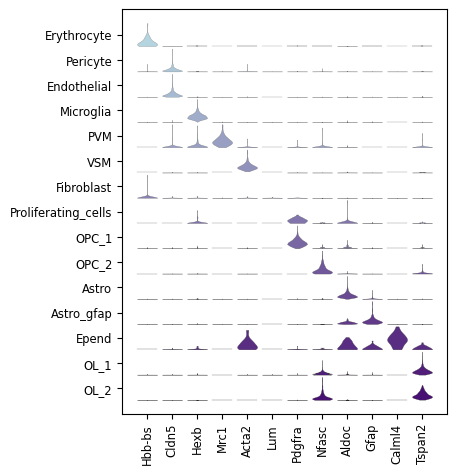

In [220]:
%matplotlib inline
sc.settings.figdir = "/bigdata/isaac/Nonneuronal_files/filtered_merged"
# Create a custom color palette
NN_palette = {k: f"{v}" for k, v in NN_m_2_c_dict.items()}
NN_custom_palette = sns.color_palette(list(NN_palette.values()))
sns.set_palette(NN_custom_palette)

sc.pl.stacked_violin(NN_adata_f, 
                     NN_violin_markers, 
                     groupby='markers', 
                     categories_order= NN_markers, 
                     #colorbar_title = 'Log/Std Expression', 
                     #vmax=2, 
                     #density_norm = 'width', 
                     row_palette = NN_custom_palette, 
                     save = 'NN_violin_markers_m2c' + today + '.pdf')

In [258]:
NN_meta_data_df_plis_fm_markers.shape

(31, 1961)

In [221]:
NN_meta_data_df_plis_fm_markers.tail()

,GATCCCTCAATACGCT-1_10X38_2,TGATGGTCACAAGCCC-1_10X37_1,GGGTGAATCAAACGTC-1_10X38_1,TAACGACAGGATCACG-1_10X37_1,AGCGTATTCCGCAACG-1_10X38_2,GCAGGCTCACTCCTGT-1_10X38_2,ATGATCGGTCTGTCCT-1_10X38_2,TGATTCTAGTTTCGGT-1_10X38_1,AATAGAGGTTCATCGA-1_10X37_1,CATCGTCCAGTTACCA-1_10X51_2,...,GCACGTGGTTATTCCT-1_10X37_1,CAAGAGGGTCAATCTG-1_10X36_2,GGTGTCGAGAAGCTGC-1_10X36_2,AAGCCATGTGGATGAC-1_10X35_1,TTCTTCCCAAGACCTT-1_10X35_1,GAGAGGTCACATCATG-1_10X37_2,ATCAGGTTCCACTAGA-1_10X35_2,TCCACGTAGAGCATCG-1_10X37_1,CTGCGAGCACTACGGC-1_10X35_2,CTCTGGTTCGAAGCAG-1_10X37_1
Sample_Index,C9,E9,B9,E9,C9,C9,C9,B9,E9,A2,...,E9,A9,A9,D9,D9,F9,G8,E9,G8,E9
cell_class,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,...,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal
cluster_label,1,1,1,1,1,1,1,1,1,1,...,15,15,15,15,15,15,15,15,15,15
markers,Erythrocyte,Erythrocyte,Erythrocyte,Erythrocyte,Erythrocyte,Erythrocyte,Erythrocyte,Erythrocyte,Erythrocyte,Erythrocyte,...,OL_2,OL_2,OL_2,OL_2,OL_2,OL_2,OL_2,OL_2,OL_2,OL_2
full_name,Nonneuronal-1-Erythrocyte,Nonneuronal-1-Erythrocyte,Nonneuronal-1-Erythrocyte,Nonneuronal-1-Erythrocyte,Nonneuronal-1-Erythrocyte,Nonneuronal-1-Erythrocyte,Nonneuronal-1-Erythrocyte,Nonneuronal-1-Erythrocyte,Nonneuronal-1-Erythrocyte,Nonneuronal-1-Erythrocyte,...,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2


Create/Save full filtered metadata (with NN)

In [ ]:
#NN_meta_data_df_plis_fm_markers = pd.read_json('/bigdata/isaac/Nonneuronal_files/filtered_merged/NNmeta_data_df_plis_f_markers_2025-02-17.json')
#NN_meta_data_df_plis_fm_markers.tail()

,GCACGTGGTTATTCCT-1_10X37_1,GAGCTGCAGCCGATCC-1_10X38_1,TGAATCGTCTATCGTT-1_10X35_2,CCGGACACATTGCCGG-1_10X37_2,CCCGGAAAGTCACTCA-1_10X35_1,GCATGATTCAAGCTTG-1_10X51_3,GATCGTAAGCGACATG-1_10X35_2,TCCTGCAAGCACTGGA-1_10X35_1,TAACCAGTCTCAACGA-1_10X35_2,TCCTTCTTCGATTTCT-1_10X52_4,...,AGGAATATCTACTTCA-1_10X52_2,CATCGTCCAAGTGGGT-1_10X52_2,ATAGGCTAGTCTGGTT-1_10X38_2,GTTACCCAGTAATCCC-1_10X36_1,AGTGATCCAGTCACGC-1_10X52_2,ACACCAAAGCGTCTGC-1_10X51_4,AATCGACGTCATAACC-1_10X37_1,GAGGGATAGAACTTCC-1_10X52_2,TGCGGCATCAAAGAAC-1_10X52_2,ATCCACCCAATTTCGG-1_10X51_3
Sample_Index,E9,B9,G8,F9,D9,B2,G8,D9,G8,G12,...,E12,E12,C9,H8,E12,C2,E9,E12,E12,B2
cell_class,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,...,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal
cluster_label,1,1,1,1,1,1,1,1,1,1,...,11,11,11,11,11,11,11,11,11,11
markers,OL_1,OL_1,OL_1,OL_1,OL_1,OL_1,OL_1,OL_1,OL_1,OL_1,...,VSM,VSM,VSM,VSM,VSM,VSM,VSM,VSM,VSM,VSM
full_name,Nonneuronal-1-OL_1,Nonneuronal-1-OL_1,Nonneuronal-1-OL_1,Nonneuronal-1-OL_1,Nonneuronal-1-OL_1,Nonneuronal-1-OL_1,Nonneuronal-1-OL_1,Nonneuronal-1-OL_1,Nonneuronal-1-OL_1,Nonneuronal-1-OL_1,...,Nonneuronal-11-VSM,Nonneuronal-11-VSM,Nonneuronal-11-VSM,Nonneuronal-11-VSM,Nonneuronal-11-VSM,Nonneuronal-11-VSM,Nonneuronal-11-VSM,Nonneuronal-11-VSM,Nonneuronal-11-VSM,Nonneuronal-11-VSM


In [222]:
gg_combined_metadata_df = pd.read_json('/bigdata/isaac/gaba_glut_combined_metadata_full_name.json')
gg_combined_metadata_df.tail()

,CTCGAGGCATCCGTTC-1_10X52_3,GTCCTCACACGACCTG-1_10X52_2,GGCTTGGGTCGGTACC-1_10X52_2,GGGAGTATCAGACCTA-1_10X52_3,CGTGCTTTCAAAGAAC-1_10X51_2,CGCAGGTTCGGTTAGT-1_10X52_1,CTACGGGCAGTCTCTC-1_10X51_2,AGGAGGTTCATTTGGG-1_10X35_1,ATCAGGTCACGAAGAC-1_10X36_2,CAAGGGAGTTCCACAA-1_10X38_2,...,CGTTCTGCAGAATCGG-1_10X51_2,GATGACTTCTGCTGAA-1_10X51_2,CATGCCTTCTGTCTCG-1_10X51_3,TTTCAGTTCCCGTTGT-1_10X38_1,ACTATTCGTGTGCCTG-1_10X38_1,TCCCATGGTTTACGAC-1_10X52_1,TGGATGTCAATTTCTC-1_10X35_2,TGGTACACATGTTACG-1_10X51_1,CTTCCGAAGGTGCCAA-1_10X36_1,CATACAGAGAGAGCAA-1_10X52_1
Sample_Index,F12,E12,E12,F12,A2,D12,A2,D9,A9,C9,...,A2,A2,B2,B9,B9,D12,G8,G1,H8,D12
cell_class,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,...,Vglut2,Vglut2,Vglut2,Vglut2,Vglut2,Vglut2,Vglut2,Vglut2,Vglut2,Vglut2
cluster_label,1,1,1,1,1,1,1,1,1,1,...,17,17,17,17,17,17,17,17,17,17
markers,Sst-Npy-Spon1,Sst-Npy-Spon1,Sst-Npy-Spon1,Sst-Npy-Spon1,Sst-Npy-Spon1,Sst-Npy-Spon1,Sst-Npy-Spon1,Sst-Npy-Spon1,Sst-Npy-Spon1,Sst-Npy-Spon1,...,Otp-Avp,Otp-Avp,Otp-Avp,Otp-Avp,Otp-Avp,Otp-Avp,Otp-Avp,Otp-Avp,Otp-Avp,Otp-Avp
full_name,GABA-1-Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1,...,Vglut2-17-Otp-Avp,Vglut2-17-Otp-Avp,Vglut2-17-Otp-Avp,Vglut2-17-Otp-Avp,Vglut2-17-Otp-Avp,Vglut2-17-Otp-Avp,Vglut2-17-Otp-Avp,Vglut2-17-Otp-Avp,Vglut2-17-Otp-Avp,Vglut2-17-Otp-Avp


In [223]:
gaba_glut_NN_combined_metadata_full_name = pd.concat((gg_combined_metadata_df,NN_meta_data_df_plis_fm_markers), axis = 1)

In [224]:
gaba_glut_NN_combined_metadata_full_name.tail()

,CTCGAGGCATCCGTTC-1_10X52_3,GTCCTCACACGACCTG-1_10X52_2,GGCTTGGGTCGGTACC-1_10X52_2,GGGAGTATCAGACCTA-1_10X52_3,CGTGCTTTCAAAGAAC-1_10X51_2,CGCAGGTTCGGTTAGT-1_10X52_1,CTACGGGCAGTCTCTC-1_10X51_2,AGGAGGTTCATTTGGG-1_10X35_1,ATCAGGTCACGAAGAC-1_10X36_2,CAAGGGAGTTCCACAA-1_10X38_2,...,GCACGTGGTTATTCCT-1_10X37_1,CAAGAGGGTCAATCTG-1_10X36_2,GGTGTCGAGAAGCTGC-1_10X36_2,AAGCCATGTGGATGAC-1_10X35_1,TTCTTCCCAAGACCTT-1_10X35_1,GAGAGGTCACATCATG-1_10X37_2,ATCAGGTTCCACTAGA-1_10X35_2,TCCACGTAGAGCATCG-1_10X37_1,CTGCGAGCACTACGGC-1_10X35_2,CTCTGGTTCGAAGCAG-1_10X37_1
Sample_Index,F12,E12,E12,F12,A2,D12,A2,D9,A9,C9,...,E9,A9,A9,D9,D9,F9,G8,E9,G8,E9
cell_class,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,...,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal,Nonneuronal
cluster_label,1,1,1,1,1,1,1,1,1,1,...,15,15,15,15,15,15,15,15,15,15
markers,Sst-Npy-Spon1,Sst-Npy-Spon1,Sst-Npy-Spon1,Sst-Npy-Spon1,Sst-Npy-Spon1,Sst-Npy-Spon1,Sst-Npy-Spon1,Sst-Npy-Spon1,Sst-Npy-Spon1,Sst-Npy-Spon1,...,OL_2,OL_2,OL_2,OL_2,OL_2,OL_2,OL_2,OL_2,OL_2,OL_2
full_name,GABA-1-Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1,...,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2,Nonneuronal-15-OL_2


In [225]:
#write to file
gaba_glut_NN_combined_metadata_full_name.to_json('/bigdata/isaac/gaba_glut_NN_combined_metadata_full_name' + today +'.json')

In [11]:
gaba_glut_NN_combined_metadata_full_name

,CTCGAGGCATCCGTTC-1_10X52_3,GTCCTCACACGACCTG-1_10X52_2,GGCTTGGGTCGGTACC-1_10X52_2,GGGAGTATCAGACCTA-1_10X52_3,CGTGCTTTCAAAGAAC-1_10X51_2,CGCAGGTTCGGTTAGT-1_10X52_1,CTACGGGCAGTCTCTC-1_10X51_2,AGGAGGTTCATTTGGG-1_10X35_1,ATCAGGTCACGAAGAC-1_10X36_2,CAAGGGAGTTCCACAA-1_10X38_2,...,AGGAATATCTACTTCA-1_10X52_2,CATCGTCCAAGTGGGT-1_10X52_2,ATAGGCTAGTCTGGTT-1_10X38_2,GTTACCCAGTAATCCC-1_10X36_1,AGTGATCCAGTCACGC-1_10X52_2,ACACCAAAGCGTCTGC-1_10X51_4,AATCGACGTCATAACC-1_10X37_1,GAGGGATAGAACTTCC-1_10X52_2,TGCGGCATCAAAGAAC-1_10X52_2,ATCCACCCAATTTCGG-1_10X51_3
Serial_Number,103.0,102.0,102.0,103.0,98.0,101.0,98.0,63.0,66.0,70.0,...,102.0,102.0,70.0,65.0,102.0,100.0,67.0,102.0,102.0,99.0
Date_Captured,05/31/20,05/31/20,05/31/20,05/31/20,05/31/20,05/31/20,05/31/20,2019-11-20,2019-11-24,2019-12-01,...,05/31/20,05/31/20,2019-12-01,2019-11-24,05/31/20,05/31/20,2019-11-25,05/31/20,05/31/20,05/31/20
Species,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,...,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm
Transcriptome,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,...,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10
Strain,C57Bl/6,C57Bl/6,C57Bl/6,C57Bl/6,C57Bl/6,C57Bl/6,C57Bl/6,,,,...,C57Bl/6,C57Bl/6,,,C57Bl/6,C57Bl/6,,C57Bl/6,C57Bl/6,C57Bl/6
Project,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,...,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph
Group,Breeder-M,Breeder-F,Breeder-F,Breeder-M,Breeder-F,Breeder-F,Breeder-F,Naïve-F,Naïve-M,Naïve-F,...,Breeder-F,Breeder-F,Naïve-F,Naïve-M,Breeder-F,Breeder-M,Naïve-M,Breeder-F,Breeder-F,Breeder-M
ChipID,10X52,10X52,10X52,10X52,10X51,10X52,10X51,10X35,10X36,10X38,...,10X52,10X52,10X38,10X36,10X52,10X51,10X37,10X52,10X52,10X51
SampleID,10X52_3,10X52_2,10X52_2,10X52_3,10X51_2,10X52_1,10X51_2,10X35_1,10X36_2,10X38_2,...,10X52_2,10X52_2,10X38_2,10X36_1,10X52_2,10X51_4,10X37_1,10X52_2,10X52_2,10X51_3
DonorID,DI-B3-M,DI-B3-F,DI-B3-F,DI-B3-M,DI-B1-F,DI-B3-F,DI-B1-F,"DI1,DI2",DI3,DI6,...,DI-B3-F,DI-B3-F,DI6,DI3,DI-B3-F,DI-B1-M,"DI4,DI5",DI-B3-F,DI-B3-F,DI-B1-M


In [226]:
Counter(gaba_glut_NN_combined_metadata_full_name.loc['Group',:])

Counter({'Breeder-F': 10240,
         'Naïve-F': 9651,
         'Naïve-M': 9548,
         'Breeder-M': 7267})

In [233]:
gaba_glut_NN_combined_metadata_full_name.loc['cell_class',:]=='GABA'

CTCGAGGCATCCGTTC-1_10X52_3     True
GTCCTCACACGACCTG-1_10X52_2     True
GGCTTGGGTCGGTACC-1_10X52_2     True
GGGAGTATCAGACCTA-1_10X52_3     True
CGTGCTTTCAAAGAAC-1_10X51_2     True
                              ...  
GAGAGGTCACATCATG-1_10X37_2    False
ATCAGGTTCCACTAGA-1_10X35_2    False
TCCACGTAGAGCATCG-1_10X37_1    False
CTGCGAGCACTACGGC-1_10X35_2    False
CTCTGGTTCGAAGCAG-1_10X37_1    False
Name: cell_class, Length: 36706, dtype: bool